# Propagation of the error and flags

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS
from src.sanity_checks import *
from src.utils import get_flag_cols, normalize_flags

path_save_fig = DATA_FIGURE / "error_propagation"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# 200 reports
fn_preprocess_reports = "dropped_preproc_text_sel_gaps_merged_df_with_clean_text_all-all_reports_with_pdf_status_020726_with_clean_text_v090726"
fn_data = "post_processed_0-778_llm_response_preproc_text_sel_gaps_combined_v300626_v060726_2016-2025_meta-llama_llama-4-scout-17b-16e-instruct_v060726_v080726_geo"
# fn_data_filtered = "filter_post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v170626_geo"
fn_data_labelled = "post_processed_labelled_reports_all_v09072026_v090726_geo"
cols = [
    "appealCode",
    "reportDate",
    "impactSubtype",
    "impactValue",
    "impactValueMin",
    "impactValueMax",
    "impactValuePrecision",
    "impactUnit",
    "valueAnnotation",
    "location",
    "locationAnnotation",
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards",
    'startYear',
    'startMonth',
    'startDay',
    'endYear',
    'endMonth',
    'endDay'
]
data_labelled = gpd.read_file(os.path.join(DATA_OUT_PROC, fn_data_labelled+'.gpkg'), ignore_geometry=True)
data = gpd.read_parquet(os.path.join(DATA_OUT_PROC, fn_data+'.parquet'))
# data_filtered = gpd.read_file(os.path.join(DATA_OUT_PROC, fn_data_filtered+'.gpkg'), ignore_geometry=True)
data_prepoc = pd.read_csv(os.path.join(DATA_IN_JSONS, fn_preprocess_reports+'.csv'), index_col=0)

In [ ]:
data_labelled = format_output(data_labelled)
# data_filtered_target = format_output(data_filtered)
data_preprocessed = format_output(data_prepoc)

## Preprocess flags

In [10]:
data_prepoc[["extraction_error"]].value_counts(normalize=False, dropna=False)


extraction_error                                           
NaN                                                            19268
ocr_unavailable                                                   21
No /Root object! - Is this really a PDF?                           6
Unexpected EOF                                                     3
file_not_found                                                     2
Unable to get page count. Is poppler installed and in PATH?        1
Name: count, dtype: int64

In [11]:
data_prepoc.loc[data_prepoc["extraction_error"].notnull(), "processing_error"] = (
    "download or extraction error"
)

In [12]:
data_prepoc[["processing_error"]].value_counts(normalize=False, dropna=False)

processing_error            
invalid appealType              12249
no natural hazard                3020
no impact text                   2027
missing origType                 1917
not in English                     55
download or extraction error       33
Name: count, dtype: int64

<Axes: ylabel='processing_error'>

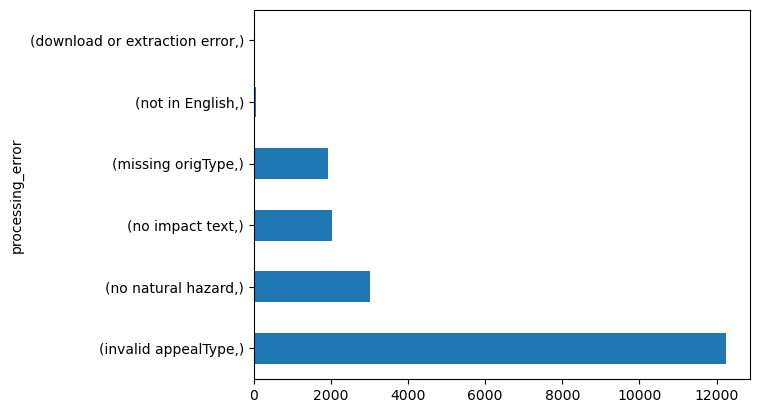

In [13]:
data_prepoc[["processing_error"]].value_counts(normalize=False, dropna=False).plot(kind="barh")


## Normalize flags

In [14]:
data = format_output(data)

In [15]:
flags_cols = get_flag_cols(data)
data[flags_cols] = data[flags_cols].map(normalize_flags)
flags_cols_lab = get_flag_cols(data_labelled)
data_labelled[flags_cols_lab] = data_labelled[flags_cols_lab].map(normalize_flags)

In [16]:
data["flag_no_location_no_country"].value_counts(normalize=False, dropna=False)

flag_no_location_no_country
False    22059
Name: count, dtype: int64

In [17]:
from src.utils import gather_flags
data = gather_flags(data, ["flag_no_location_no_country", "flag_country_location_missing"], flag_name="test", how="any")

In [18]:
data["test"].value_counts(normalize=False, dropna=False)

test
False    22020
True        39
Name: count, dtype: int64

In [19]:
flags_cols

['valid_errors_impactValue',
 'valid_errors_loc',
 'valid_errors_haz',
 'valid_errors_dates',
 'flag_value_not_in_text',
 'flag_missing_startYear',
 'flag_missing_endYear',
 'flag_missing_startMonth',
 'flag_missing_endMonth',
 'flag_missing_startDay',
 'flag_missing_endDay',
 'flag_startYear_after_endYear',
 'flag_inconsistent_year',
 'flag_inconsistent_month',
 'flag_inconsistent_day',
 'flag_impactSubtype_reclass',
 'flag_unknown_subtype',
 'flag_hazards_reclass',
 'flag_hazards_unknown',
 'flag_remove_number_unit',
 'flag_remove_number_unit_error',
 'flag_SI_unit_standardization',
 'flag_SI_unit_standardization_error',
 'flag_unit_harmonization',
 'flag_non_currency_unit_conversion',
 'flag_non_currency_unit_conversion_error',
 'flag_non-SI_unit_standardization_error',
 'flag_non-SI_unit_standardization',
 'flag_people_unit_normalization',
 'flag_currency_conversion',
 'flag_currency_conversion_error',
 'flag_reclass_subtype_from_unit',
 'flag_impactSubtype_merged',
 'flag_inferred

## Process / harmonize flags

In [20]:
def combine_flags(df, new_flag, source_flags, how="any", warn_missing=True):
    """
    Combine several boolean flags into a new flag.

    Parameters
    ----------
    df : pd.DataFrame
    new_flag : str
        Name of the output flag.
    source_flags : list[str]
        Flags to combine.
    how : {"any", "all"}
        Aggregation method.
    warn_missing : bool
        Whether to warn about missing source flags.
    """
    flags_in = [f for f in source_flags if f in df.columns]

    if warn_missing:
        missing = sorted(set(source_flags) - set(flags_in))
        if missing:
            print(f"Warning: Missing flags for '{new_flag}': {missing}")

    if not flags_in:
        df[new_flag] = False
        return df

    values = df[flags_in].fillna(False).astype(bool)

    if how == "all":
        df[new_flag] = values.all(axis=1)
    elif how == "any":
        df[new_flag] = values.any(axis=1)
    else:
        raise ValueError(f"Unknown aggregation method: {how}")

    return df


def drop_flags(df, flags):
    """Drop flags if they exist."""
    return df.drop(columns=[f for f in flags if f in df.columns])


# ---------------------------------------------------------------------
# Create missing flags
# ---------------------------------------------------------------------

# if "flag_years_missing" not in df.columns:
#    df["flag_years_missing"] = df.apply(flag_years_missing, axis=1)


# ---------------------------------------------------------------------
# Flag combinations
# ---------------------------------------------------------------------

FLAG_GROUPS = {
    "flag_impactSubtype_reclass": (
        [
            "flag_impactSubtype_reclass",
            "flag_reclass_subtype_from_unit",
            "flag_impactSubtype_merged",
        ],
        "any",
    ),
    "flag_years_missing_after_inference": (
        [
            "flag_failed_startYear_inference",
            "flag_years_missing",
        ],
        "all",
    ),
    "flag_remove_unit": (
        [
            "flag_remove_unit",
            "flag_response_unit",
        ],
        "any",
    ),
    "flag_incorrect_unit": (
        [
            "flag_partial_unit",
            "flag_unit_nonstd",
            "flag_percent",
        ],
        "any",
    ),
    "flag_unit_harmonization": (
        [
            "flag_people_unit_normalization",
            "flag_non-SI_unit_standardization",
            "flag_SI_unit_standardization",
            "flag_unit_harmonization",
            "flag_remove_number_unit",
        ],
        "any",
    ),
    "flag_unit_conversion": (
        [
            "flag_currency_conversion",
            "flag_unit_conversion",
            "flag_non_currency_unit_conversion",
        ],
        "any",
    ),
    "flag_unit_harmonization_error": (
        [
            "flag_remove_number_unit_error",
            "flag_SI_unit_standardization_error",
            "flag_non-SI_unit_standardization_error",
        ],
        "any",
    ),
    "flag_country_location_missing": (
        [
            "flag_no_location_no_country",
            "flag_country_location_missing",
        ],
        "any",
    ),
    "flag_unit_conversion_error": (
        [
            "flag_unit_conversion_error",
            "flag_currency_conversion_error",
            "flag_non_currency_unit_conversion_error",
        ],
        "any",
    ),
}

for new_flag, (flags, how) in FLAG_GROUPS.items():
    combine_flags(data, new_flag, flags, how)
    combine_flags(data_labelled, new_flag, flags, how)


# ---------------------------------------------------------------------
# Drop obsolete flags
# ---------------------------------------------------------------------

FLAGS_TO_DROP = [
    "flag_reclass_subtype_from_unit",
    "flag_impactSubtype_merged",
    "flag_percent",
    "flag_partial_unit",
    "flag_unit_nonstd",
    "flag_people_unit_normalization",
    "flag_non-SI_unit_standardization",
    "flag_SI_unit_standardization",
    "flag_remove_number_unit",
    "flag_remove_number_unit_error",
    "flag_SI_unit_standardization_error",
    "flag_non-SI_unit_standardization_error",
    "flag_currency_conversion_error",
    "flag_non_currency_unit_conversion",
    "flag_non_currency_unit_conversion_error",
    "flag_response_unit",
    "flag_years_missing",
    "flag_currency_conversion",
    "flag_no_location_no_country",
]

data = drop_flags(data, FLAGS_TO_DROP)
data_labelled = drop_flags(data_labelled, FLAGS_TO_DROP)

In [21]:
# filter flags
unwanted_flags = [  # flags to filter out (i.e. keep only rows for which these flags are False)
    "flag_remove_cat",
    #"flag_value_no_unit",
    "flag_incorrect_unit",
    #"flag_unit_nonstd",
    #"flag_response_unit",
    "flag_unknown_subtype",
    "flag_all_hazards_unknown",
    "flag_pop_cntry",
    # "flag_value_not_in_text",
    "flag_no_location_no_country",
    "flag_country_location_missing",
    "flag_remove_unit",
    "flag_remove_hazard",
    "flag_years_missing_after_inference",
    #"flag_failed_startYear_inference",
    #"flag_inconsistent_year",
]

data_filtered = data[~data[[flag for flag in unwanted_flags if flag in data.columns]].any(axis=1)]
data_labelled_filtered = data_labelled[~data_labelled[[flag for flag in unwanted_flags if flag in data_labelled.columns]].any(axis=1)]
results_dict = {"pre-filter": data, "post-filter": data_filtered, "post-filter-labelled": data_labelled_filtered, "pre-filter-labelled": data_labelled}

In [22]:
# check count of error and flag cols for both dataframes
for df_name, df in results_dict.items():

    error_cols = [col for col in df.columns if "error" in col]
    flag_cols = [
        col
        for col in df.columns
        if col.startswith("flag_") or col.startswith("valid_")
    ]
    print(f"DataFrame: {df_name}")
    print(f"Number of error columns: {len(error_cols)}")
    print(f"Number of flag columns: {len(flag_cols)}")

DataFrame: pre-filter
Number of error columns: 6
Number of flag columns: 41
DataFrame: post-filter
Number of error columns: 6
Number of flag columns: 41
DataFrame: post-filter-labelled
Number of error columns: 2
Number of flag columns: 36
DataFrame: pre-filter-labelled
Number of error columns: 2
Number of flag columns: 36


## Plots

In [23]:
dict_flag_name_plot = {
    "flag_value_not_in_text" : "Value not in text",
    "flag_percent" : "Unit Percentage",
    "flag_unit_not_in_text" : "Unit not in text",
    "flag_value_no_unit" : "Value without unit",
    "flag_incorrect_unit" : "Incorrect unit",
    "flag_unit_correction" : "Unit corrected",
}

In [24]:
flags_by_type = {
    "Extraction errors": [
        "valid_errors_impactSubtype",
        "valid_errors_impactValue",
        "valid_errors_loc",
        "valid_errors_haz",
        "valid_errors_dates",
    ],
    "Post-processing": [
        "flag_impactSubtype_reclass",
        "flag_unit_harmonization",
        "flag_unit_conversion",
        "flag_hazards_reclass",
        "flag_inferred_startYear",
        # "flag_fail_country_iso",
        # "flag_location_to_country",
        "flag_osm_polygon",
        "flag_nomin_translate",
    ],
    "Post-processing errors": [
        "flag_unit_harmonization_error",
        "flag_unit_conversion_error",
        "flag_failed_startYear_inference",
        "flag_fail_country_iso",
        "flag_nomin_no_result",
        "flag_nomin_sim_below_th",
    ],
    "Warnings": [
        "flag_value_no_unit",
        "flag_hazards_unknown",
        "flag_value_not_in_text",
        "flag_missing_startYear",
        "flag_missing_endYear",
        "flag_missing_startMonth",
        "flag_missing_endMonth",
        "flag_missing_startDay",
        "flag_missing_endDay",
        "flag_startYear_after_endYear",
        "flag_inconsistent_year",
        "flag_inconsistent_month",
        "flag_inconsistent_day",
        "flag_location_to_country",
        # "flag_osm_polygon",
        "flag_no_location",
    ],
    "Error removals": [
        "flag_unknown_subtype",
        "flag_incorrect_unit",
        "flag_all_hazards_unknown",
        "flag_years_missing_after_inference",
        "flag_no_location_no_country",
        "flag_country_location_missing",
        "flag_pop_cntry",
    ],
    "Controlled removals": [
        "flag_remove_cat",
        "flag_remove_unit",
        "flag_remove_hazard",
    ],
}

In [25]:
# check missing flags
plot_flags = [flag for flags in flags_by_type.values() for flag in flags]
missing_flags = [flag for flag in flag_cols if flag not in plot_flags]

In [26]:
missing_flags

[]

In [27]:
# separate between processing/warning flags and flags that remove rows
flags_by_category = {
    "Impact subtype": [
        "valid_errors_impactSubtype",
        "flag_impactSubtype_reclass",
        "flag_reclass_subtype_from_unit",
        "flag_impactSubtype_merged",
        "flag_unknown_subtype",
        "flag_remove_cat",
    ],
    "Impact value & unit": [
        "flag_incorrect_unit",
        "valid_errors_impactValue",
        #"flag_remove_number_unit",
        "flag_unit_harmonization",
        "flag_unit_conversion",
        #"flag_SI_unit_standardization",
        #"flag_non-SI_unit_standardization",
        #"flag_people_unit_normalization",
        #"flag_currency_conversion",
        #"flag_percent",
        #"flag_unit_nonstd",
        "flag_value_no_unit",
        #"flag_partial_unit",
        "flag_value_not_in_text",
        "flag_unit_conversion_error",
        "flag_pop_cntry",
        #"flag_remove_number_unit_error",
        #"flag_SI_unit_standardization_error",
        #"flag_non-SI_unit_standardization_error",
        "flag_unit_harmonization_error",
        #"flag_currency_conversion_error",
        "flag_remove_unit",
        #"flag_response_unit",
    ],
    "Hazards": [
        "valid_errors_haz",
        "flag_hazards_reclass",
        "flag_hazards_unknown",
        "flag_remove_hazard",
        "flag_all_hazards_unknown",
    ],
    "Dates": [
        "valid_errors_dates",
        "flag_missing_startYear",
        "flag_missing_endYear",
        "flag_missing_startMonth",
        "flag_missing_endMonth",
        "flag_missing_startDay",
        "flag_missing_endDay",
        "flag_startYear_after_endYear",
        "flag_inconsistent_year",
        "flag_inconsistent_month",
        "flag_inconsistent_day",
        "flag_inferred_startYear",
        "flag_failed_startYear_inference",
        "flag_years_missing",
        "flag_years_missing_after_inference",
    ],
    "Locations": [
        "valid_errors_loc",
        # "flag_geocoding_country",
        # "flag_geocoding_osm",
        "flag_fail_country_iso",
        "flag_location_to_country",
        "flag_osm_polygon",
        "flag_no_location",
        "flag_nomin_no_result",
        "flag_nomin_sim_below_th",
        "flag_nomin_translate",
        "flag_no_location_no_country",
        "flag_country_location_missing",
    ],
}

In [28]:
# check missing flags
plot_flags = [flag for flags in flags_by_category.values() for flag in flags]
missing_flags = [flag for flag in flag_cols if flag not in plot_flags]

In [29]:
missing_flags

[]

In [30]:
missing_flags

[]

In [31]:
from matplotlib.patches import Patch
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def count_flag(df, flag):
    if flag not in df.columns:
        return 0
    return int(df[flag].fillna(False).astype(bool).sum())


def count_rows_with_any_flag(df, flags):
    existing_flags = [flag for flag in flags if flag in df.columns]
    if not existing_flags:
        return 0
    return int(df[existing_flags].fillna(False).astype(bool).any(axis=1).sum())


def label_color(bg):
    rgb = mcolors.to_rgb(bg)
    luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]

    if luminance > 0.6:
        # Light background → dark text
        return tuple(c * 0.45 for c in rgb)
    else:
        # Dark background → light text
        return tuple(1 - (1 - c) * 0.35 for c in rgb)


def darken(color, factor=0.55):
    """Return a darker shade of a hex color."""
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

In [32]:
from matplotlib.patches import Patch

#PLOT_FONT_FAMILY = "DejaVu Sans"
PLOT_AXIS_LABEL_SIZE = 15
PLOT_TICK_LABEL_SIZE = 13
PLOT_ANNOTATION_SIZE = 12
PLOT_TITLE_SIZE = 17
PLOT_LEGEND_SIZE = 13


def plot_pre_post_counts(
    ax,
    df,
    y,
    labels,
    colors,
    xlabel,
    x_max,
    x_ticks,
    legend=False,
    title="",
    count_label="perc",
    bold_mask=None,
    red_mask=None,
):
    """Plot pre/post-filter horizontal stacked bar plot."""

    ax.figure.set_facecolor("white")
    ax.set_facecolor("white")

    # Bars
    ax.barh(
        y,
        df["kept_count"],
        color=colors,
        edgecolor="#2f2f2f",
        linewidth=0.8,
        zorder=2,
    )

    ax.barh(
        y,
        df["dropped_count"],
        left=df["kept_count"],
        color="#d9d9d9",
        edgecolor="#6f6f6f",
        hatch="///",
        linewidth=0.8,
        zorder=2,
    )

    if df["added_count"].gt(0).any():
        ax.barh(
            y,
            df["added_count"],
            left=df["pre_count"],
            color="white",
            edgecolor="#d62728",
            hatch="...",
            linewidth=1.1,
            zorder=2,
        )

    # Text
    for ypos, row in zip(y, df.itertuples()):
        if count_label == "perc" and hasattr(row, "pre_count_perc") and hasattr(row, "post_count_perc"):
            label = (
                f"post {row.post_count_perc:.1f}% / "
                f"pre {row.pre_count_perc:.1f}%"
            )
        elif count_label == "count":
            label = f"post {row.post_count} / pre {row.pre_count}"
        elif count_label == "both" and hasattr(row, "pre_count_perc") and hasattr(row, "post_count_perc"):
            label = (
                f"post {row.post_count} ({row.post_count_perc:.1f}%) / "
                f"pre {row.pre_count} ({row.pre_count_perc:.1f}%)"
            )
        else:
            label = ""
        ax.annotate(
            label,
            xy=(max(row.pre_count, row.post_count), ypos),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            fontsize=PLOT_ANNOTATION_SIZE,
            fontweight="bold" if getattr(row, "row_type", "") != "flag" else "normal",
            annotation_clip=False,
            clip_on=False,
        )

    # Axis
    ax.set_yticks(y)
    ax.set_yticklabels(
        labels,
        fontsize=PLOT_TICK_LABEL_SIZE,
        #fontfamily=PLOT_FONT_FAMILY,
        fontweight="normal",
    )

    if bold_mask is not None:
        for tick, bold in zip(ax.get_yticklabels(), bold_mask):
            if bold:
                tick.set_fontweight("bold")
                tick.set_fontsize(PLOT_TICK_LABEL_SIZE)

    if red_mask is not None:
        for tick, red in zip(ax.get_yticklabels(), red_mask):
            if red:
                tick.set_color(unwanted_flag_color)
                tick.set_fontweight("bold")

    ax.set_xlim(0, x_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])

    ax.tick_params(axis="x", rotation=35, labelsize=PLOT_TICK_LABEL_SIZE)

    ax.grid(axis="x", linestyle=":", alpha=0.35)

    ax.invert_yaxis()
    ax.set_ylim(len(df) - 0.5, -0.5)
    ax.margins(y=0)

    ax.set_xlabel(xlabel, fontsize=PLOT_AXIS_LABEL_SIZE)
    ax.set_title(title, fontsize=PLOT_TITLE_SIZE, fontweight="bold", pad=10, loc="left")
    if legend:
        handles = [
            Patch(
                facecolor="#888888",
                edgecolor="#2f2f2f",
                label="Final count",
            ),
            Patch(
                facecolor="#d9d9d9",
                edgecolor="#6f6f6f",
                hatch="///",
                label="Dropped from final filter",
            ),
        ]

        if df["added_count"].gt(0).any():
            handles.append(
                Patch(
                    facecolor="white",
                    edgecolor="#d62728",
                    hatch="...",
                    label="Post-filter exceeds pre-filter",
                )
            )

        ax.legend(
            handles=handles,
            frameon=True,
            fontsize=PLOT_LEGEND_SIZE,
            loc="lower right",
        )
    return ax.get_figure()

In [33]:
save = True
count_label = "perc"
savename = "figure4"
savename += f"_{count_label}" if count_label is not None else ""
flag_dict = flags_by_type
source_dict = results_dict
pre_df = source_dict["pre-filter"]
post_df = source_dict["post-filter"]
category_colors = {
    "Extraction errors": "#F4D29D",
    "Post-processing": "#EFB784",
    "Post-processing errors": "#E89A73",
    "Warnings": "#DD7E67",
    "Error removals": "#C45454",
    "Controlled removals": "#60798B",
}


type_colors = {
    "Impact subtype": "#bebc9a",
    "Impact value & unit": "#ca6702",
    "Hazards": "#5c4cac",
    "Dates": "#96bb99",
    "Locations": "#457b9d",
}
unwanted_flag_color = "#d62728"
try:
    unwanted_flag_set = set(unwanted_flags)
except NameError:
    unwanted_flag_set = set()


plot_rows = []
category_spans = []
all_flags = []

for category, flags in flag_dict.items():
    existing_flags = [
        flag for flag in flags if flag in pre_df.columns or flag in post_df.columns
    ]
    if not existing_flags:
        continue

    flag_rows = []
    for flag in dict.fromkeys(existing_flags):
        pre_count = count_flag(pre_df, flag)
        post_count = count_flag(post_df, flag)
        flag_rows.append(
            {
                "label": flag,
                "category": category,
                "row_type": "flag",
                "pre_count": pre_count,
                "post_count": post_count,
                "color": category_colors.get(category, "#666666"),
            }
        )
        all_flags.append(flag)

    flag_rows = sorted(flag_rows, key=lambda row: (row["pre_count"], row["label"]))
    start = len(plot_rows)
    plot_rows.extend(flag_rows)

    pre_total = count_rows_with_any_flag(pre_df, existing_flags)
    post_total = count_rows_with_any_flag(post_df, existing_flags)
    plot_rows.append(
        {
            "label": f"{category} total",
            "category": category,
            "row_type": "category_total",
            "pre_count": pre_total,
            "post_count": post_total,
            "color": category_colors.get(category, "#666666"),
        }
    )
    end = len(plot_rows) - 1
    category_spans.append((category, start, end))

unique_all_flags = list(dict.fromkeys(all_flags))
plot_rows.append(
    {
        "label": "All groups total",
        "category": "All groups",
        "row_type": "all_total",
        "pre_count": count_rows_with_any_flag(pre_df, unique_all_flags),
        "post_count": count_rows_with_any_flag(post_df, unique_all_flags),
        "color": "#1f1f1f",
    }
)

plot_df = pd.DataFrame(plot_rows)
plot_df["kept_count"] = plot_df[["pre_count", "post_count"]].min(axis=1)
plot_df["dropped_count"] = (plot_df["pre_count"] - plot_df["post_count"]).clip(lower=0)
plot_df["added_count"] = (plot_df["post_count"] - plot_df["pre_count"]).clip(lower=0)

all_total_counts = plot_df.loc[
    (plot_df["label"] == "All groups total")
    & (plot_df["category"] == "All groups"),
    ["pre_count", "post_count"],
].iloc[0]
plot_df["pre_count_perc"] = np.where(
    all_total_counts["pre_count"] > 0,
    plot_df["pre_count"] / len(pre_df) * 100,
    0,
)
plot_df["post_count_perc"] = np.where(
    all_total_counts["post_count"] > 0,
    plot_df["post_count"] / len(post_df) * 100,
    0,
)

y_positions = np.arange(len(plot_df))
fig_height = max(6, 0.36 * len(plot_df))
max_count = int(plot_df[["pre_count", "post_count"]].max().max()) if len(plot_df) else 0
x_padding = 4 * max(2, int(np.ceil(max_count * 0.06)))
x_max = max_count + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)


summary_rows = []
for category, flags in flags_by_category.items():
    pre_count = count_rows_with_any_flag(pre_df, flags)
    post_count = count_rows_with_any_flag(post_df, flags)
    kept_count = min(pre_count, post_count)
    dropped_count = max(pre_count - post_count, 0)
    added_count = max(post_count - pre_count, 0)
    summary_rows.append(
        {
            "category": category,
            "pre_count": pre_count,
            "post_count": post_count,
            "kept_count": kept_count,
            "dropped_count": dropped_count,
            "added_count": added_count,
        }
    )

category_summary = pd.DataFrame(summary_rows)
category_summary = category_summary.sort_values(
    "pre_count", ascending=True
).reset_index(drop=True)
category_summary["pre_count_perc"] = np.where(
    all_total_counts["pre_count"] > 0,
    category_summary["pre_count"] / len(pre_df) * 100,
    0,
)
category_summary["post_count_perc"] = np.where(
    all_total_counts["post_count"] > 0,
    category_summary["post_count"] / len(post_df) * 100,
    0,
)

y_positions_S= np.arange(len(category_summary))
fig_height_S = max(4.5, 0.55 * len(category_summary))
max_count_S = (
    int(category_summary[["pre_count", "post_count"]].max().max())
    if len(category_summary)
    else 0
)
x_padding_S = max(2, int(np.ceil(max_count_S * 0.06)))
x_max_S = max_count_S + x_padding_S
x_tick_step_S = 500
x_ticks_S = np.arange(0, x_max_S + x_tick_step_S, x_tick_step_S)

combined_x_tick_step = 500
combined_max_count = max(max_count, max_count_S)
combined_x_padding = max(600, int(np.ceil(combined_max_count * 0.28)))
combined_x_max = combined_max_count + combined_x_padding
combined_x_ticks = np.arange(
    0, combined_x_max + combined_x_tick_step, combined_x_tick_step
)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/171236289.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return int(df[flag].fillna(False).astype(bool).sum())
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/171236289.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return int(df[existing_flags].fillna(False).astype(bool).any(axis=1).sum())
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/171236289.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and 

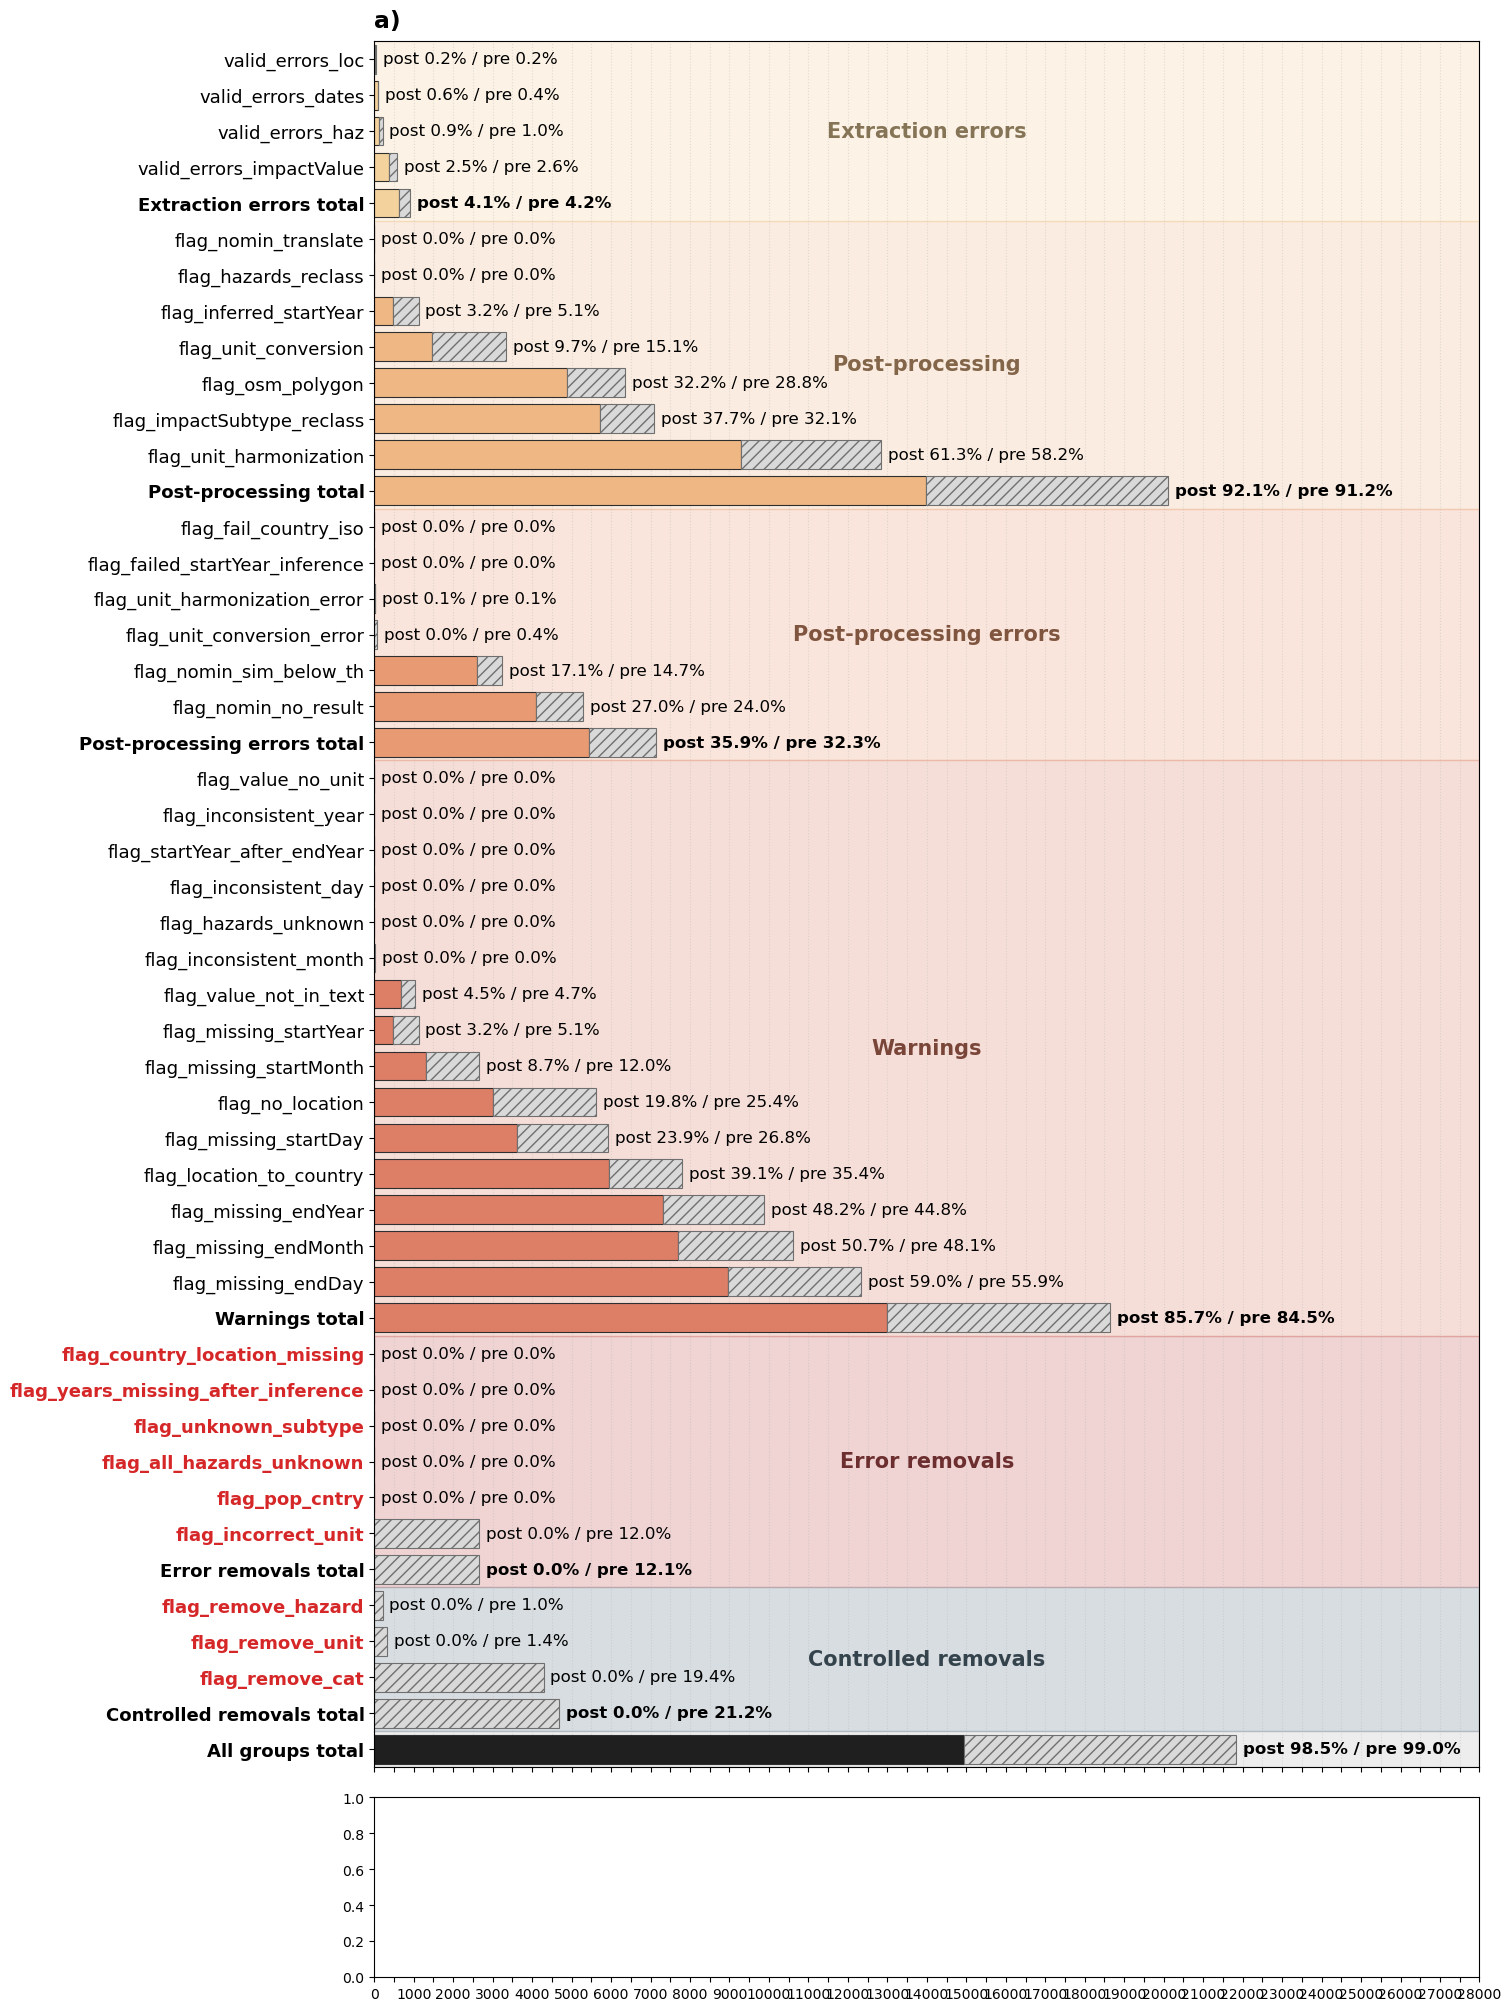

In [34]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 20),
    constrained_layout=True,
    height_ratios=[len(plot_df), len(category_summary)],
    sharex=True,
)
# Background spans
for category, start, end in category_spans:

    bg = category_colors.get(category, "#d9d9d9")

    axes[0].axhspan(
        start - 0.5,
        end + 0.5,
        color=bg,
        alpha=0.25,
        zorder=0,
    )

    axes[0].text(
        0.5,
        start + (end - start) / 2,
        category,
        transform=axes[0].get_yaxis_transform(),
        ha="center",
        va="center",
        fontsize=PLOT_AXIS_LABEL_SIZE,
        fontweight="bold",
        #fontfamily=PLOT_FONT_FAMILY,
        color=darken(bg),
        #bbox={
        #    "facecolor": "white",
        #    "edgecolor": "none",
        #    "boxstyle": "round,pad=0.25",
        #    "alpha": 0.78,
        #},
        clip_on=False,
        zorder=5,
    )

axes[0].axhspan(
    len(plot_df) - 1.5,
    len(plot_df) - 0.5,
    color="#1f1f1f",
    alpha=0.08,
    zorder=0,
)

fig = plot_pre_post_counts(
    axes[0],
    plot_df,
    np.arange(len(plot_df)),
    plot_df["label"],
    plot_df["color"],
    "",
    combined_x_max,
    combined_x_ticks,
    legend=False,
    title="a)",
    count_label=count_label,
    bold_mask=plot_df["row_type"] != "flag",
    red_mask=plot_df["label"].isin(unwanted_flag_set),
)

In [35]:
summary_colors = [
    type_colors.get(cat, "#666666") for cat in category_summary["category"]
]

fig = plot_pre_post_counts(
    axes[1],
    category_summary,
    np.arange(len(category_summary)),
    category_summary["category"],
    summary_colors,
    "Flag count (#)",
    combined_x_max,
    combined_x_ticks,
    count_label=count_label,
    title="b)",
    legend=False,
)

legend_handles = [
    Patch(
        facecolor="#888888",
        edgecolor="#2f2f2f",
        label="Final count",
    ),
    Patch(
        facecolor="#d9d9d9",
        edgecolor="#6f6f6f",
        hatch="///",
        label="Dropped from final filter",
    ),
]
if plot_df["added_count"].gt(0).any() or category_summary["added_count"].gt(0).any():
    legend_handles.append(
        Patch(
            facecolor="white",
            edgecolor="#d62728",
            hatch="...",
            label="Post-filter exceeds pre-filter",
        )
    )

axes[0].legend(
    handles=legend_handles,
    loc=(0.74,1),
    ncol=1,#len(legend_handles),
    frameon=False,
    fontsize=PLOT_LEGEND_SIZE,
)
fig

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(
        os.path.join(path_save_fig, f"{savename}.svg"),
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

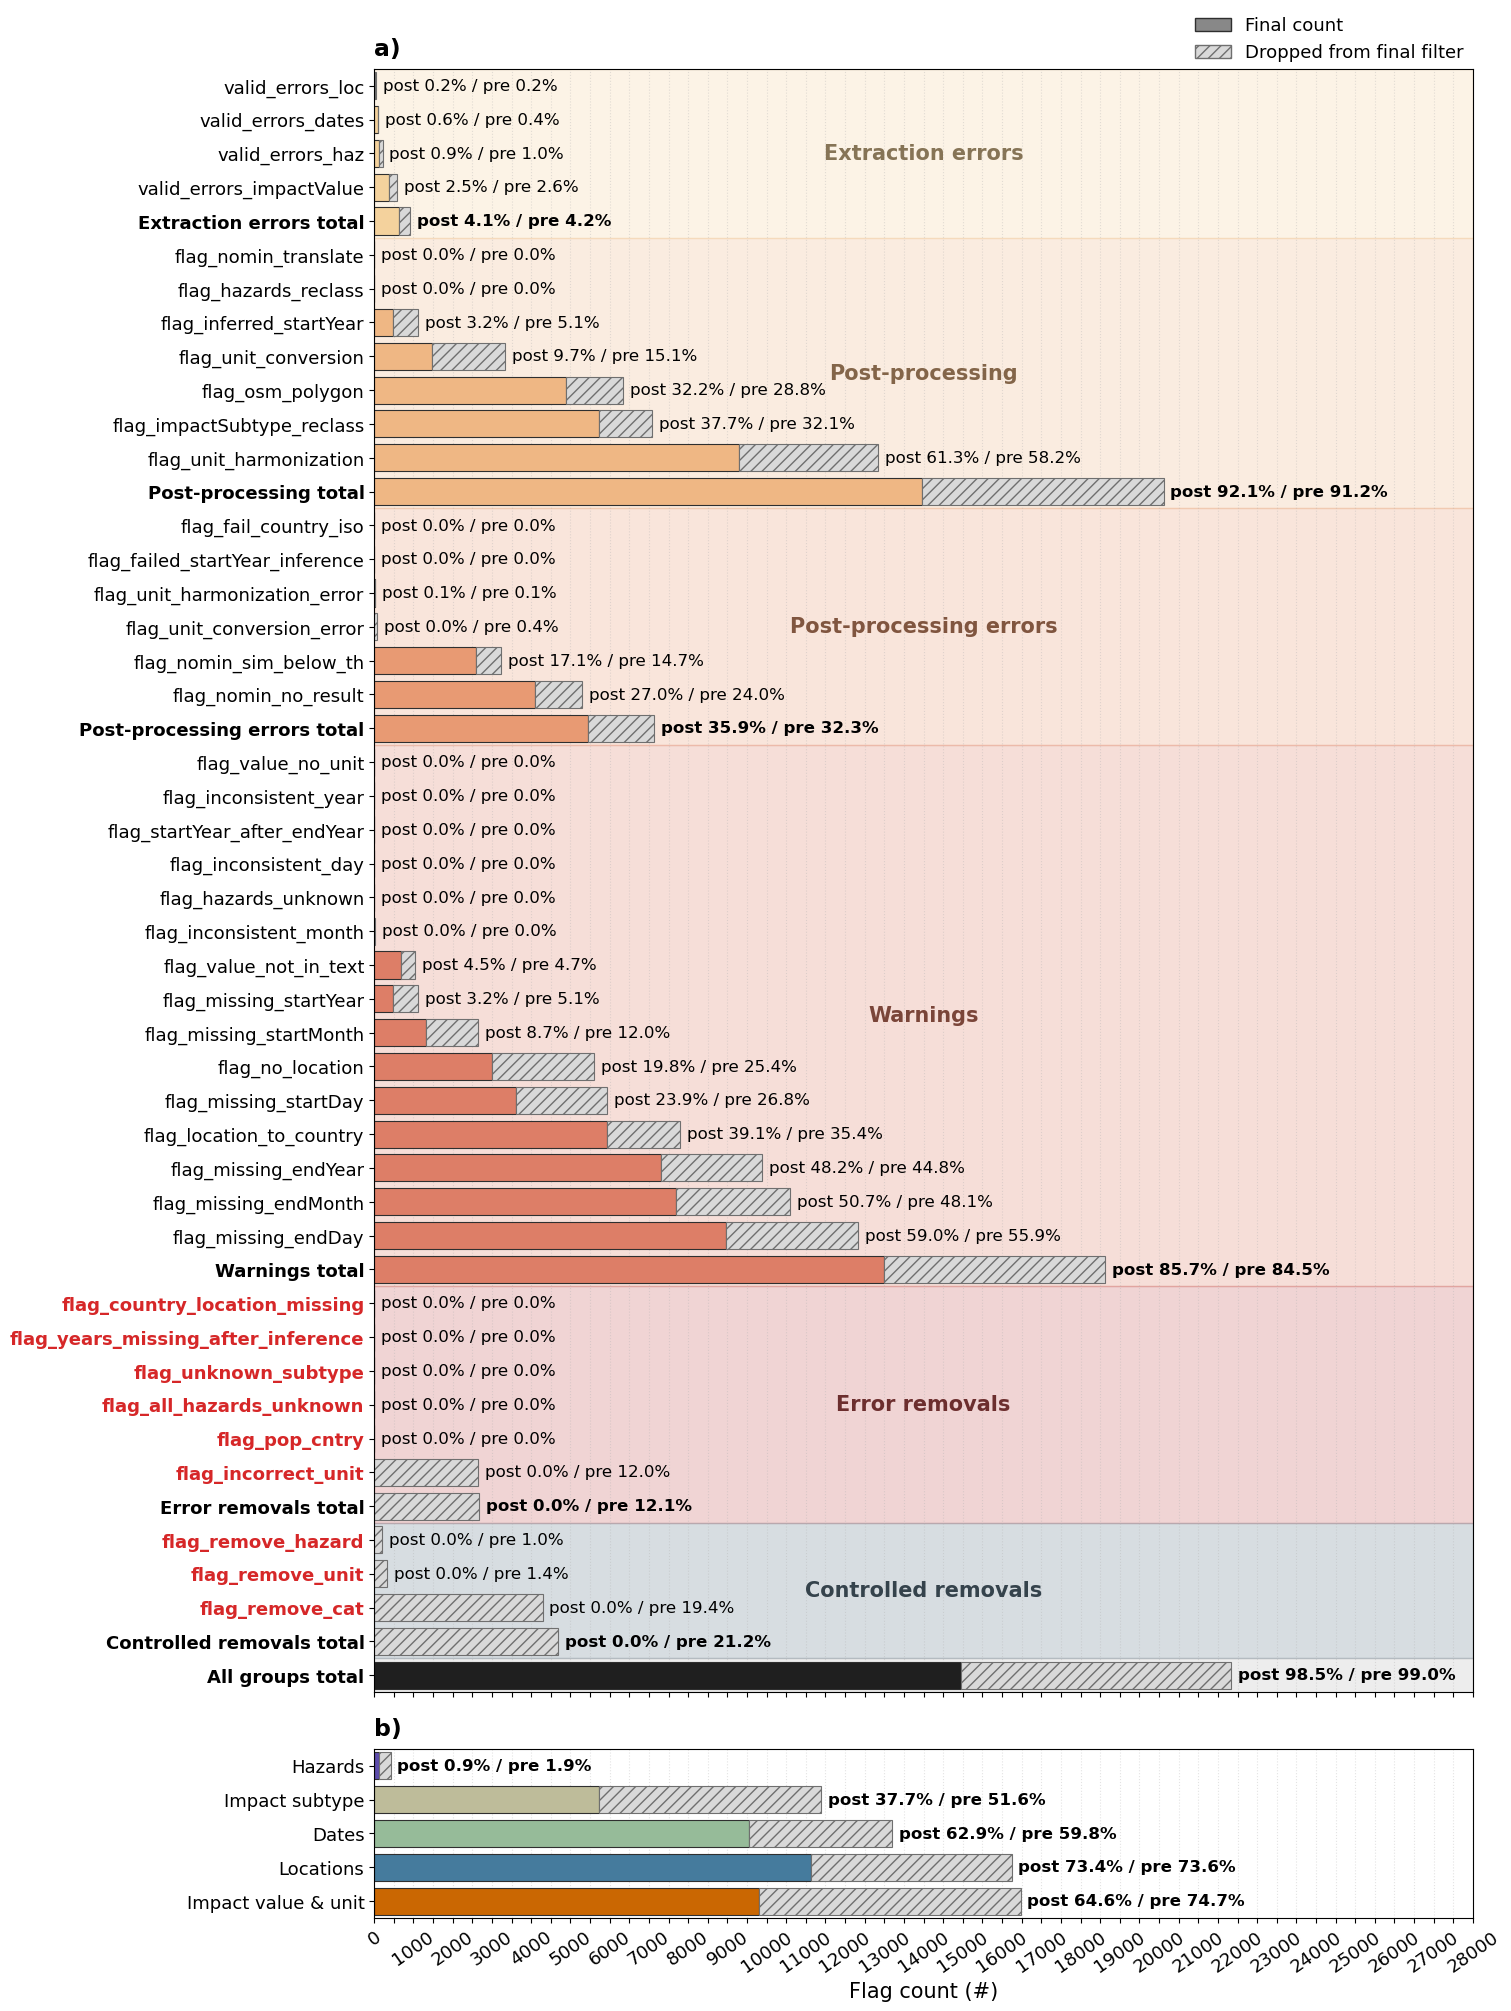

In [36]:
fig

In [37]:
plot_df

,label,category,row_type,pre_count,post_count,color,kept_count,dropped_count,added_count,pre_count_perc,post_count_perc
0,valid_errors_loc,Extraction errors,flag,39,32,#F4D29D,32,7,0,0.176799,0.210929
1,valid_errors_dates,Extraction errors,flag,95,89,#F4D29D,89,6,0,0.430663,0.586646
2,valid_errors_haz,Extraction errors,flag,211,131,#F4D29D,131,80,0,0.956526,0.863490
3,valid_errors_impactValue,Extraction errors,flag,582,381,#F4D29D,381,201,0,2.638379,2.511370
4,Extraction errors total,Extraction errors,category_total,917,626,#F4D29D,626,291,0,4.157033,4.126294
5,flag_nomin_translate,Post-processing,flag,0,0,#EFB784,0,0,0,0.000000,0.000000
6,flag_hazards_reclass,Post-processing,flag,3,0,#EFB784,0,3,0,0.013600,0.000000
7,flag_inferred_startYear,Post-processing,flag,1122,479,#EFB784,479,643,0,5.086359,3.157340
8,flag_unit_conversion,Post-processing,flag,3335,1470,#EFB784,1470,1865,0,15.118546,9.689539
9,flag_osm_polygon,Post-processing,flag,6351,4882,#EFB784,4882,1469,0,28.790970,32.179817


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/171236289.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return int(df[flag].fillna(False).astype(bool).sum())
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/171236289.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return int(df[existing_flags].fillna(False).astype(bool).any(axis=1).sum())
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/171236289.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and 

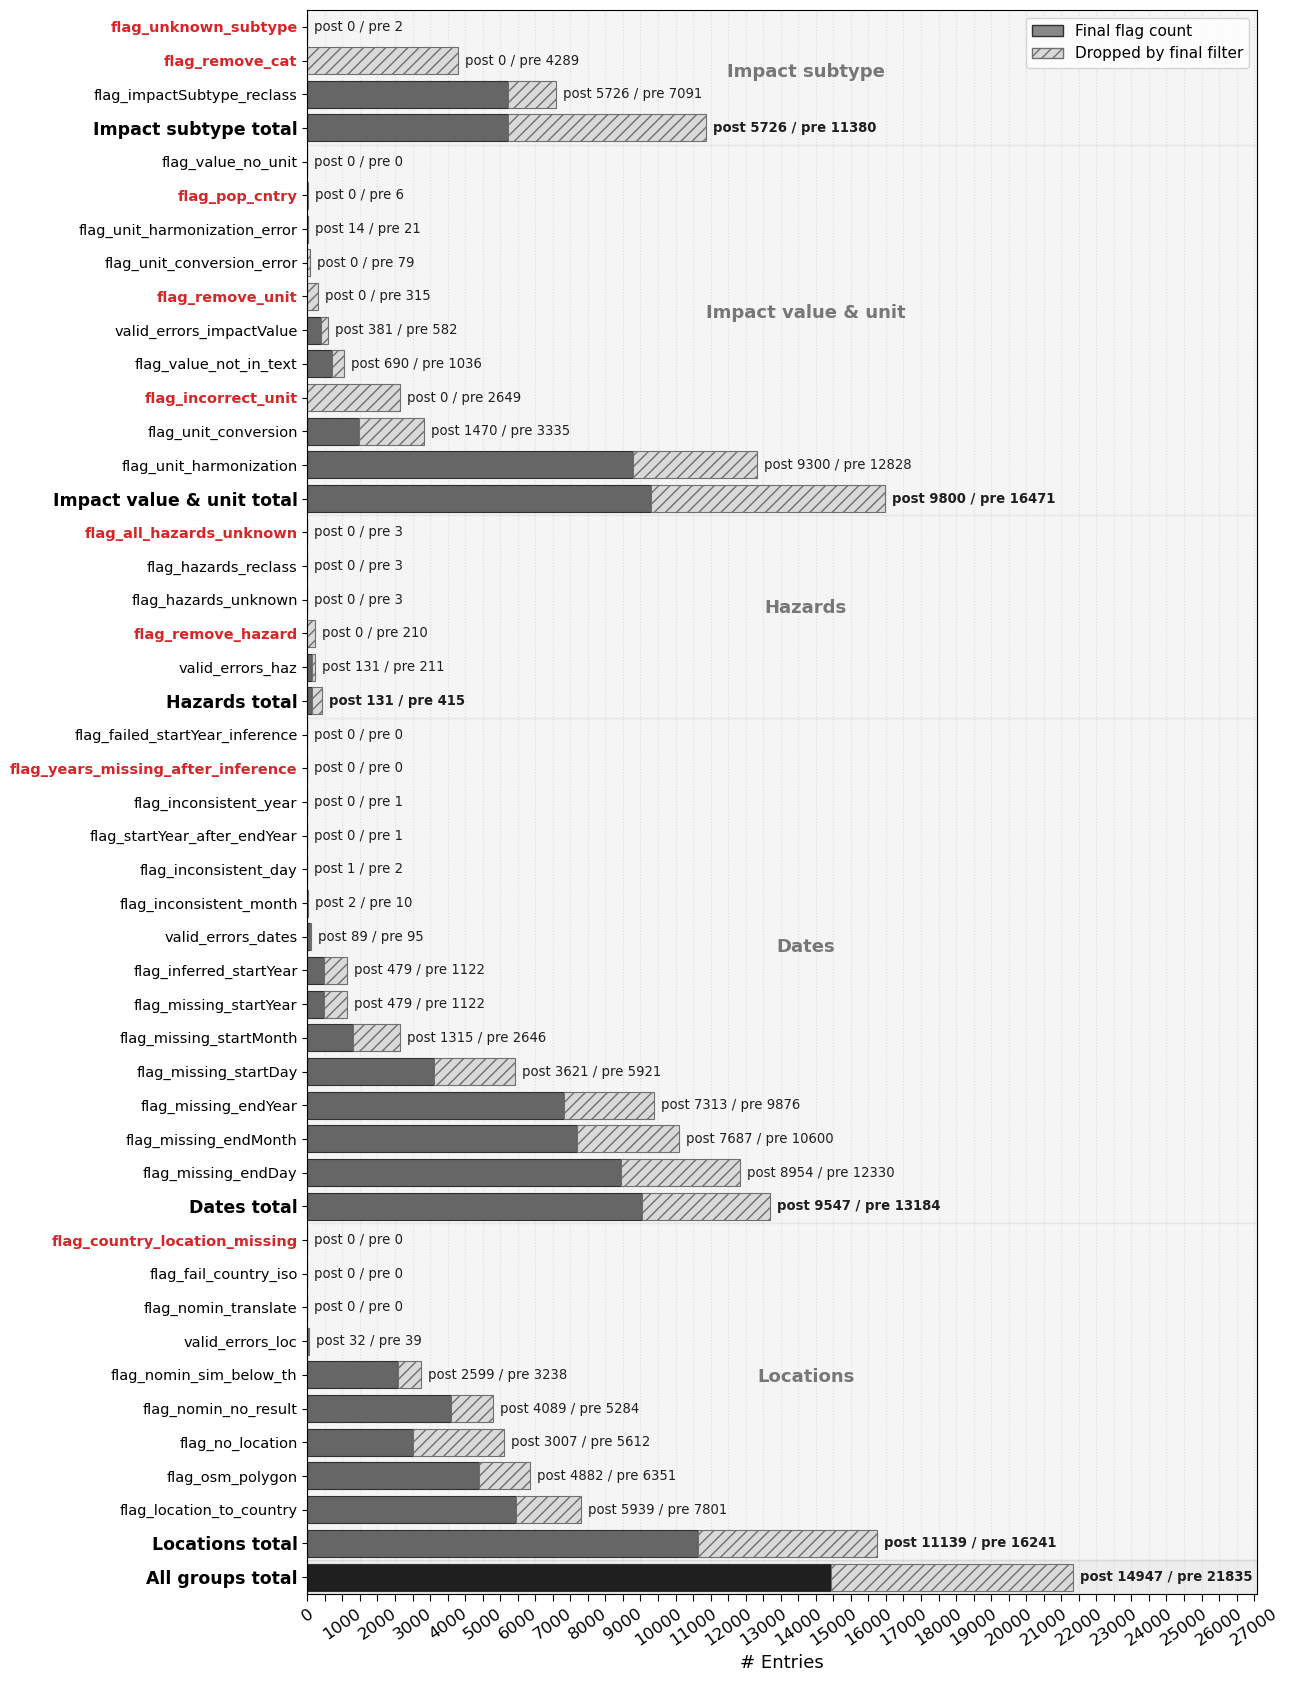

In [38]:

save = False
savename = "validation_flags_detailed_pre_post_delta"
flag_dict = flags_by_category
source_dict = results_dict
pre_df = source_dict["pre-filter"]
post_df = source_dict["post-filter"]
category_colors = {
    "Extraction errors": "#F4D29D",
    "Postprocessing": "#EFB784",
    "Postprocessing errors": "#E89A73",
    "Warnings": "#DD7E67",
    "Error removals": "#C45454",
    "Controlled removals": "#60798B",
}
# category_colors = {  # Earthy terra cotta tones
#    "Extraction errors": "#ecc8af",
#    "Postprocessing": "#e7ad99",
#    "Postprocessing errors": "#ce796b",
#    "Warnings": "#c18c5d",
#    "Error removals": "#d62728",
#    "Controlled removals": "#495867",
# }
# category_colors = { #muted earthy tones
#   "Subtype": "#FFCDB2",  # "#bebc9a",
#   "Value & Unit": "#FFB4A2",  # "#ca6702",
#   "Hazard": "#E5989B",  # "#5c4cac",
#   "Dates": "#B5838D",  # "#96bb99",
#   "Location": "#6D6875",  # "#457b9d",
# }
# category_colors = {  # Earthy terra cotta tones
#    "Subtype":"#ecc8af",
#    "Value & Unit":"#e7ad99",
#    "Hazard":"#ce796b",
#    "Dates":"#c18c5d",
#    "Location":"#495867"
# }
# category_colors = {  # custom
#   "Subtype": "#bebc9a",
#   "Value & Unit": "#ca6702",
#   "Hazard": "#5c4cac",
#   "Dates": "#96bb99",
#   "Location": "#457b9d",
# }
# category_colors = {  #
#    "Subtype": "#0081a7",
#    "Value & Unit": "#00afb9",
#    "Hazard": "#fdfcdc",
#    "Dates": "#fed9b7",
#    "Location": "#f07167",
# }
# category_colors = {  #
#    "Subtype": "#0d3b66",
#    "Value & Unit": "#faf0ca",
#    "Hazard": "#f4d35e",
#    "Dates": "#ee964b",
#    "Location": "#f95738",
# }
# category_colors = {  #
#    "Subtype": "#335c67",
#    "Value & Unit": "#fff3b0",
#    "Hazard": "#e09f3e",
#    "Dates": "#9e2a2b",
#    "Location": "#540b0e",
# }
unwanted_flag_color = "#d62728"
try:
    unwanted_flag_set = set(unwanted_flags)
except NameError:
    unwanted_flag_set = set()


plot_rows = []
category_spans = []
all_flags = []

for category, flags in flag_dict.items():
    existing_flags = [
        flag for flag in flags if flag in pre_df.columns or flag in post_df.columns
    ]
    if not existing_flags:
        continue

    flag_rows = []
    for flag in dict.fromkeys(existing_flags):
        pre_count = count_flag(pre_df, flag)
        post_count = count_flag(post_df, flag)
        flag_rows.append(
            {
                "label": flag,
                "category": category,
                "row_type": "flag",
                "pre_count": pre_count,
                "post_count": post_count,
                "color": category_colors.get(category, "#666666"),
            }
        )
        all_flags.append(flag)

    flag_rows = sorted(flag_rows, key=lambda row: (row["pre_count"], row["label"]))
    start = len(plot_rows)
    plot_rows.extend(flag_rows)

    pre_total = count_rows_with_any_flag(pre_df, existing_flags)
    post_total = count_rows_with_any_flag(post_df, existing_flags)
    plot_rows.append(
        {
            "label": f"{category} total",
            "category": category,
            "row_type": "category_total",
            "pre_count": pre_total,
            "post_count": post_total,
            "color": category_colors.get(category, "#666666"),
        }
    )
    end = len(plot_rows) - 1
    category_spans.append((category, start, end))

unique_all_flags = list(dict.fromkeys(all_flags))
plot_rows.append(
    {
        "label": "All groups total",
        "category": "All groups",
        "row_type": "all_total",
        "pre_count": count_rows_with_any_flag(pre_df, unique_all_flags),
        "post_count": count_rows_with_any_flag(post_df, unique_all_flags),
        "color": "#1f1f1f",
    }
)

plot_df = pd.DataFrame(plot_rows)
plot_df["kept_count"] = plot_df[["pre_count", "post_count"]].min(axis=1)
plot_df["dropped_count"] = (plot_df["pre_count"] - plot_df["post_count"]).clip(lower=0)
plot_df["added_count"] = (plot_df["post_count"] - plot_df["pre_count"]).clip(lower=0)

y_positions = np.arange(len(plot_df))
fig_height = max(6, 0.36 * len(plot_df))
max_count = int(plot_df[["pre_count", "post_count"]].max().max()) if len(plot_df) else 0
x_padding = 4 * max(2, int(np.ceil(max_count * 0.06)))
x_max = max_count + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)

fig, ax = plt.subplots(figsize=(13, fig_height))
ax.set_axisbelow(True)

for category, start, end in category_spans:
    bg = category_colors.get(category, "#d9d9d9")
    ax.axhspan(
        start - 0.5,
        end + 0.5,
        color=bg,
        alpha=0.25,
        zorder=0,
    )

    ax.text(
        x_max * 0.525,
        start + (end - start) * 0.45,
        category,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=darken(bg),
        zorder=1.5,
    )
ax.axhspan(
    len(plot_df) - 1.5,
    len(plot_df) - 0.5,
    color="#1f1f1f",
    alpha=0.08,
    zorder=0,
)

ax.barh(
    y_positions,
    plot_df["kept_count"],
    color=plot_df["color"],
    edgecolor="#2f2f2f",
    linewidth=0.8,
    label="Post-filter count",
    zorder=2,
)
ax.barh(
    y_positions,
    plot_df["dropped_count"],
    left=plot_df["kept_count"],
    color="#d9d9d9",
    edgecolor="#6f6f6f",
    linewidth=0.8,
    hatch="///",
    label="Dropped by post-filter",
    zorder=2,
)

if plot_df["added_count"].gt(0).any():
    ax.barh(
        y_positions,
        plot_df["added_count"],
        left=plot_df["pre_count"],
        color="#ffffff",
        edgecolor="#d62728",
        linewidth=1.1,
        hatch="...",
        label="Post-filter exceeds pre-filter",
        zorder=2,
    )

for y_pos, row in plot_df.iterrows():
    label_weight = "bold" if row["row_type"] != "flag" else "normal"
    ax.annotate(
        f"post {row['post_count']} / pre {row['pre_count']}",
        xy=(max(row["pre_count"], row["post_count"]), y_pos),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight=label_weight,
        color="#1f1f1f",
        zorder=4,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["label"], fontsize=10.5)
for tick_label, row_type in zip(ax.get_yticklabels(), plot_df["row_type"]):
    if row_type != "flag":
        tick_label.set_fontweight("bold")
        tick_label.set_fontsize(12.5)
    elif tick_label.get_text() in unwanted_flag_set:  # Only apply to the right panel
        tick_label.set_color(unwanted_flag_color)
        tick_label.set_fontweight("bold")

ax.set_xticks(x_ticks)
ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])
ax.tick_params(axis="x", which="major", length=5, labelrotation=35, labelsize=12)
ax.set_xlim(0, x_max)
ax.set_xlabel("# Entries", fontsize=13)
# ax.set_title(
#    "Validation flags: detailed pre-filter vs post-filter counts", fontsize=15, pad=12
# )
ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

ax.invert_yaxis()
ax.set_ylim(len(plot_df) - 0.5, -0.5)
ax.margins(y=0)

legend_handles = [
    Patch(facecolor="#888888", edgecolor="#2f2f2f", label="Final flag count"),
    Patch(
        facecolor="#d9d9d9",
        edgecolor="#6f6f6f",
        hatch="///",
        label="Dropped by final filter",
    ),
]
if plot_df["added_count"].gt(0).any():
    legend_handles.append(
        Patch(
            facecolor="#ffffff",
            edgecolor="#d62728",
            hatch="...",
            label="Post-filter exceeds pre-filter",
        )
    )
ax.legend(handles=legend_handles, fontsize=11, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(
        os.path.join(path_save_fig, f"{savename}.png"), dpi=300, bbox_inches="tight"
    )

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/171236289.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return int(df[existing_flags].fillna(False).astype(bool).any(axis=1).sum())


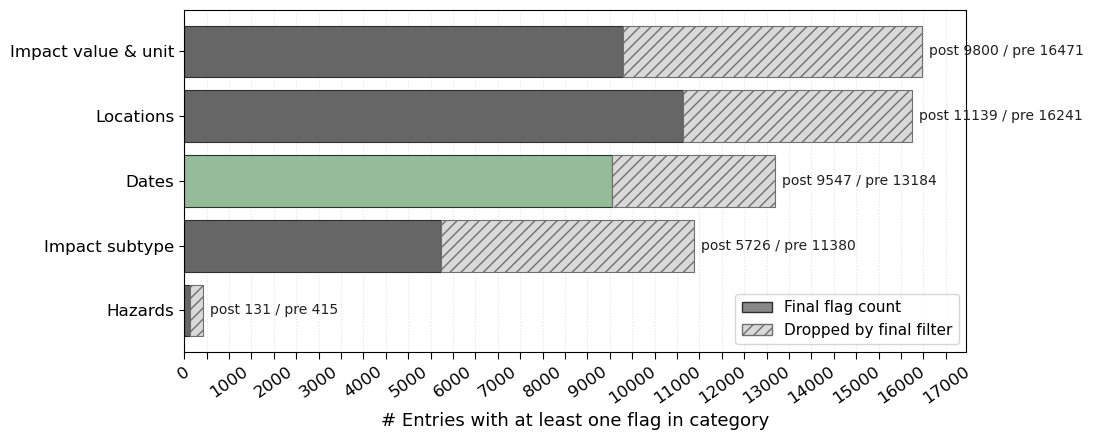

In [39]:
save = False
savename = "validation_flags_category_pre_post_delta"

source_dict = results_dict
pre_df = source_dict["pre-filter"]
post_df = source_dict["post-filter"]

category_colors = {
    "Subtype": "#bebc9a",
    "Value & Unit": "#ca6702",
    "Hazard": "#5c4cac",
    "Dates": "#96bb99",
    "Location": "#457b9d",
}

summary_rows = []
for category, flags in flags_by_category.items():
    pre_count = count_rows_with_any_flag(pre_df, flags)
    post_count = count_rows_with_any_flag(post_df, flags)
    kept_count = min(pre_count, post_count)
    dropped_count = max(pre_count - post_count, 0)
    added_count = max(post_count - pre_count, 0)
    summary_rows.append(
        {
            "category": category,
            "pre_count": pre_count,
            "post_count": post_count,
            "kept_count": kept_count,
            "dropped_count": dropped_count,
            "added_count": added_count,
        }
    )

category_summary = pd.DataFrame(summary_rows)
category_summary = category_summary.sort_values(
    "pre_count", ascending=True
).reset_index(drop=True)

y_positions = np.arange(len(category_summary))
fig_height = max(4.5, 0.55 * len(category_summary))
max_count = (
    int(category_summary[["pre_count", "post_count"]].max().max())
    if len(category_summary)
    else 0
)
x_padding = max(2, int(np.ceil(max_count * 0.06)))
x_max = max_count + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)

fig, ax = plt.subplots(figsize=(11, fig_height))
ax.set_axisbelow(True)

bar_colors = [
    category_colors.get(category, "#666666")
    for category in category_summary["category"]
]
ax.barh(
    y_positions,
    category_summary["kept_count"],
    color=bar_colors,
    edgecolor="#2f2f2f",
    linewidth=0.8,
    label="Post-filter count",
    zorder=2,
)
ax.barh(
    y_positions,
    category_summary["dropped_count"],
    left=category_summary["kept_count"],
    color="#d9d9d9",
    edgecolor="#6f6f6f",
    linewidth=0.8,
    hatch="///",
    label="Dropped by post-filter",
    zorder=2,
)

if category_summary["added_count"].gt(0).any():
    ax.barh(
        y_positions,
        category_summary["added_count"],
        left=category_summary["pre_count"],
        color="#ffffff",
        edgecolor="#d62728",
        linewidth=1.1,
        hatch="...",
        label="Post-filter exceeds pre-filter",
        zorder=2,
    )

for y_pos, row in category_summary.iterrows():
    ax.annotate(
        f"post {row['post_count']} / pre {row['pre_count']}",
        xy=(max(row["pre_count"], row["post_count"]), y_pos),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=10,
        color="#1f1f1f",
        zorder=4,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(category_summary["category"], fontsize=12)
ax.set_xticks(x_ticks)
ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])
ax.tick_params(axis="x", which="major", length=5, labelrotation=35, labelsize=12)
ax.set_xlim(0, x_max)
ax.set_xlabel("# Entries with at least one flag in category", fontsize=13)
#ax.set_title(
#    "Validation flags by category: pre-filter vs post-filter", fontsize=15, pad=12
#)
ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

legend_handles = [
    Patch(facecolor="#888888", edgecolor="#2f2f2f", label="Final flag count"),
    Patch(
        facecolor="#d9d9d9",
        edgecolor="#6f6f6f",
        hatch="///",
        label="Dropped by final filter",
    ),
]
if category_summary["added_count"].gt(0).any():
    legend_handles.append(
        Patch(
            facecolor="#ffffff",
            edgecolor="#d62728",
            hatch="...",
            label="Post-filter exceeds pre-filter",
        )
    )
ax.legend(handles=legend_handles, fontsize=11, loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(
        os.path.join(path_save_fig, f"{savename}.png"), dpi=300, bbox_inches="tight"
    )

## Legacy plots

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/1187769955.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/1187769955.py:174: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  int(panel_df[flag].fillna(False).astype(bool).sum())
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_93333/1187769955.py:192: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_object

KeyError: 'Impact subtype'

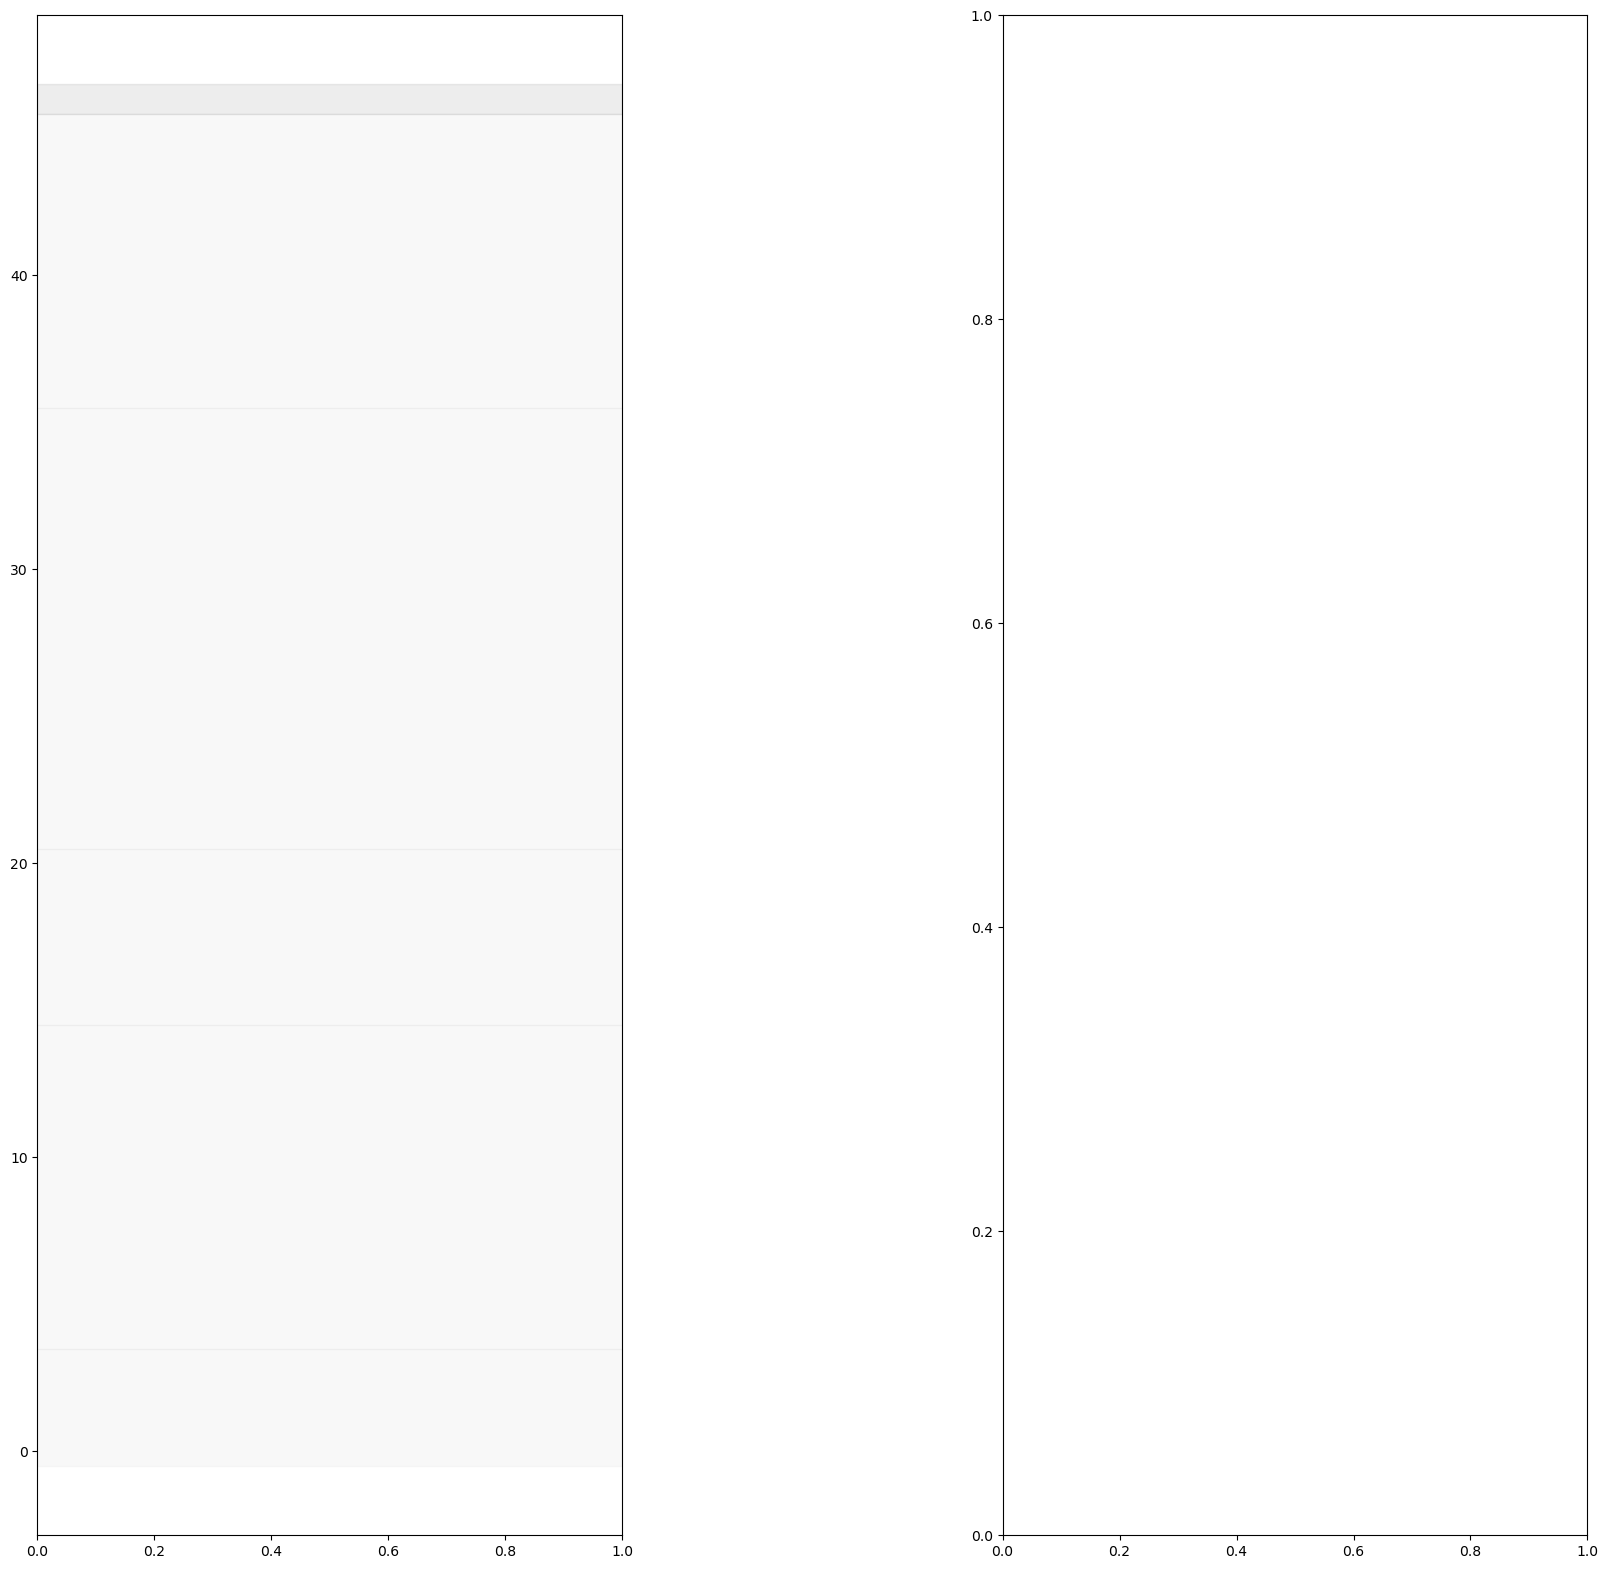

In [40]:
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save = True
savename = "vali" \
"dation_flags_warnings_remove"

# -----------------------------------------------------------------------------
# Colors
# -----------------------------------------------------------------------------

category_palette = {
    "Subtype processing": "#bebc9a",
    "Subtype remove": "#bebc9a",
    "Value & Unit processing": "#ca6702",
    "Value & Unit qualitative conversion": "#ca6702",
    "Value & Unit remove": "#ca6702",
    "Hazard processing": "#5c4cac",
    "Hazard remove": "#5c4cac",
    "Dates processing": "#96bb99",
    "Dates remove": "#96bb99",
    "Location processing": "#457b9d",
    "Location remove": "#457b9d",
    "Other": "#999999",
}

domain_color_map = {
    "Subtype": category_palette["Subtype processing"],
    "Value & Unit": category_palette["Value & Unit processing"],
    "Hazard": category_palette["Hazard processing"],
    "Dates": category_palette["Dates processing"],
    "Location": category_palette["Location processing"],
}
unwanted_flag_color = "#d62728"
try:
    unwanted_flag_set = set(unwanted_flags)
except NameError:
    unwanted_flag_set = set()

# -----------------------------------------------------------------------------
# Use only the full dataframe
# -----------------------------------------------------------------------------
source_dict = results_dict
# source_df = results_dict["pre-filter"]
# source_df_filtered = results_dict["post-filter"]

# -----------------------------------------------------------------------------
# Pair warning and removal groups so the row height is shared by domain
# -----------------------------------------------------------------------------

# flag_group_pairs = [
#    ("Subtype", ["Subtype processing"], ["Subtype remove"]),
#    (
#        "Value & Unit",
#        ["Value & Unit processing"],
#        ["Value & Unit qualitative conversion", "Value & Unit remove"],
#    ),
#    ("Hazard", ["Hazard processing"], ["Hazard remove"]),
#    ("Dates", ["Dates processing"], ["Dates remove"]),
#    ("Location", ["Location processing"], ["Location remove"]),
# ]


def ordered_group_flags(flag_dict, group_names, df):
    ordered = []
    flag_to_category = {}
    spans = []

    for group_name in group_names:
        existing_flags = [
            flag for flag in flag_dict.get(group_name, []) if flag in df.columns
        ]

        if not existing_flags:
            continue

        group_counts = (
            df[existing_flags]
            .fillna(False)
            .astype(bool)
            .sum()
            .sort_values(ascending=True)
        )

        start = len(ordered)
        ordered.extend(group_counts.index.tolist())

        for flag in group_counts.index:
            flag_to_category[flag] = group_name

        end = len(ordered) - 1
        spans.append((group_name, start, end))

    return ordered, flag_to_category, spans


panel_data = {
    "Pre-filter flags": [],
    "Post-filter flags": [],
}
group_layout = []
y_start = 0

for domain_name, groups in flags_by_category.items():
    pre_flags_ordered, pre_flags_categories, pre_flags_spans = ordered_group_flags(
        flags_by_category, [domain_name], source_dict["pre-filter"]
    )

    post_flags_ordered, post_flags_categories, post_flags_spans = ordered_group_flags(
        flags_by_category, [domain_name], source_dict["post-filter"]
    )

    aligned_flags = list(dict.fromkeys(pre_flags_ordered + post_flags_ordered))
    aligned_categories = {
        flag: pre_flags_categories.get(
            flag, post_flags_categories.get(flag, domain_name)
        )
        for flag in aligned_flags
    }

    if not aligned_flags:
        continue

    group_height = len(aligned_flags) + 1

    group_layout.append((domain_name, y_start, y_start + group_height - 1))

    panel_data["Pre-filter flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": aligned_flags,
            "flag_to_category": aligned_categories,
            "spans": pre_flags_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )
    panel_data["Post-filter flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": aligned_flags,
            "flag_to_category": aligned_categories,
            "spans": post_flags_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )

    y_start += group_height

all_total_y = y_start
total_y_rows = y_start + 1
all_ordered_flags = [
    flag
    for panel_groups in panel_data.values()
    for group in panel_groups
    for flag in group["ordered_flags"]
]

# -----------------------------------------------------------------------------
# Counts and figure setup
# -----------------------------------------------------------------------------

panel_sources = {
    "Pre-filter flags": source_dict["pre-filter"],
    "Post-filter flags": source_dict["post-filter"],
}
unique_ordered_flags = pd.Index(all_ordered_flags).unique()
flag_counts_by_panel = {
    panel_title: pd.Series(
        [
            int(panel_df[flag].fillna(False).astype(bool).sum())
            for flag in unique_ordered_flags
            if flag in panel_df.columns
        ],
        index=[flag for flag in unique_ordered_flags if flag in panel_df.columns],
        dtype=int,
    )
    for panel_title, panel_df in panel_sources.items()
}
add_total_rows = False
total_rows = max(len(panel_df) for panel_df in panel_sources.values())
label = "total number of rows with at least one flag"
all_total_counts = {}
for panel_title, panel_df in panel_sources.items():
    panel_total_flags = [
        flag for flag in unique_ordered_flags if flag in panel_df.columns
    ]
    all_total_counts[panel_title] = (
        int(panel_df[panel_total_flags].fillna(False).astype(bool).any(axis=1).sum())
        if panel_total_flags
        else 0
    )
max_flag_count = max(
    (counts.max() for counts in flag_counts_by_panel.values() if len(counts)), default=0
)
max_total_count = max(all_total_counts.values(), default=0)
max_x = max(total_rows, max_flag_count, max_total_count)
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)
fig_height = max(5.5, 0.42 * total_y_rows)

fig, axes = plt.subplots(
    ncols=2,
    figsize=(20, fig_height),
    gridspec_kw={"wspace": 0.65},
)

for ax, (panel_title, panel_groups) in zip(axes, panel_data.items()):
    is_right_panel = ax is axes[1]
    panel_df = panel_sources[panel_title]
    flag_counts = flag_counts_by_panel[panel_title]
    ax.set_axisbelow(True)

    # -------------------------------------------------------------------------
    # Shared domain shading
    # -------------------------------------------------------------------------

    for domain_name, start, end in group_layout:
        ax.axhspan(
            start - 0.5,
            end + 0.5,
            color="#d9d9d9",
            alpha=0.16,
            zorder=0,
        )
    ax.axhspan(
        all_total_y - 0.5,
        all_total_y + 0.5,
        color="#1f1f1f",
        alpha=0.08,
        zorder=0,
    )

    # -------------------------------------------------------------------------
    # Side-specific group labels, bars, value labels, and error overlays
    # -------------------------------------------------------------------------

    for group in panel_groups:
        y_offset = group["y_offset"]
        ordered_flags = group["ordered_flags"]
        flag_to_category = group["flag_to_category"]
        domain_start = group["y_offset"]
        domain_end = domain_start + group["group_height"] - 1

        domain_color = domain_color_map[group["domain"]]

        panel_ordered_flags = [
            flag for flag in ordered_flags if flag in panel_df.columns
        ]
        group_total = (
            int(
                panel_df[panel_ordered_flags]
                .fillna(False)
                .astype(bool)
                .any(axis=1)
                .sum()
            )
            if panel_ordered_flags
            else 0
        )

        ax.axhspan(
            domain_start - 0.5,
            domain_end + 0.5,
            color=domain_color,
            alpha=0.18,
            zorder=0.2,
        )

        ax.text(
            x_max * 0.525,
            domain_start + (domain_end - domain_start) * 0.65,
            f"{group['domain']}\n ({group_total} entries)",
            ha="center",
            va="center",
            fontsize=13,
            color=domain_color,
            alpha=0.95,
            zorder=1.5,
        )

        y_positions = y_offset + np.arange(len(ordered_flags))
        counts = flag_counts.reindex(ordered_flags).fillna(0).astype(int)
        bar_colors = [
            (
                unwanted_flag_color
                if is_right_panel and flag in unwanted_flag_set
                else category_palette.get(
                    flag_to_category.get(flag, "Other"), "#666666"
                )
            )
            for flag in ordered_flags
        ]

        ax.barh(
            y_positions,
            counts.values,
            color=bar_colors,
            edgecolor="#2f2f2f",
            linewidth=0.8,
            zorder=2,
        )

        for y_pos, flag_name, flag_count in zip(
            y_positions,
            ordered_flags,
            counts.values,
        ):
            ax.annotate(
                f"{flag_count}",
                xy=(flag_count, y_pos),
                xytext=(4, 0),
                textcoords="offset points",
                va="center",
                ha="left",
                fontsize=10,
                color="#1f1f1f",
                zorder=4,
            )

            error_col = f"{flag_name}_error"

            if error_col in panel_df.columns:
                error_count = int(panel_df[error_col].fillna(False).astype(bool).sum())

                if error_count > 0:
                    ax.hlines(
                        y_pos,
                        0,
                        min(error_count, flag_count),
                        colors="#1f1f1f",
                        linestyles="--",
                        linewidth=2.2,
                        zorder=3,
                    )

        total_y = y_offset + len(ordered_flags)
        ax.barh(
            total_y,
            group_total,
            color=domain_color,
            edgecolor="#1f1f1f",
            linewidth=1.1,
            zorder=2.5,
        )
        ax.annotate(
            f"{group_total}",
            xy=(group_total, total_y),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
            color="#1f1f1f",
            zorder=4,
        )

    all_total_count = all_total_counts[panel_title]
    ax.barh(
        all_total_y,
        all_total_count,
        color="#1f1f1f",
        edgecolor="#1f1f1f",
        linewidth=1.1,
        zorder=2.5,
    )
    ax.annotate(
        f"{all_total_count}",
        xy=(all_total_count, all_total_y),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#1f1f1f",
        zorder=4,
    )

    # -------------------------------------------------------------------------
    # Total rows reference line and styling
    # -------------------------------------------------------------------------

    if add_total_rows:
        for _, start, end in group_layout:
            ax.vlines(
                total_rows,
                start - 0.5,
                end + 0.5,
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                zorder=4,
            )

    ax.set_title(panel_title, fontsize=16, pad=12)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])
    ax.tick_params(axis="x", which="major", length=5, labelrotation=35, labelsize=13)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("# Entries", fontsize=15)
    ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

y_labels = [""] * total_y_rows
for group in panel_data["Pre-filter flags"]:
    for idx, flag in enumerate(group["ordered_flags"]):
        y_labels[group["y_offset"] + idx] = flag
    y_labels[group["y_offset"] + len(group["ordered_flags"])] = (
        f"{group['domain']} total"
    )
y_labels[all_total_y] = "All groups total"

for ax in axes:
    ax.set_yticks(np.arange(total_y_rows))
    ax.set_yticklabels(y_labels, fontsize=12)

for label in axes[1].get_yticklabels():
    if label.get_text() in unwanted_flag_set:
        label.set_color(unwanted_flag_color)
        label.set_fontweight("bold")
for ax in axes:
    ax.set_ylim(total_y_rows - 0.5, -0.5)

if add_total_rows:
    axes[1].legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                label=f"{label} ({total_rows})",
            ),
        ],
        fontsize=12,
        loc="lower right",
        frameon=True,
    )

plt.tight_layout()
plt.show()

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(
        os.path.join(path_save_fig, f"{savename}.png"), dpi=300, bbox_inches="tight"
    )

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_84180/2194274744.py:80: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_84180/2194274744.py:80: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_84180/2194274744.py:170: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the

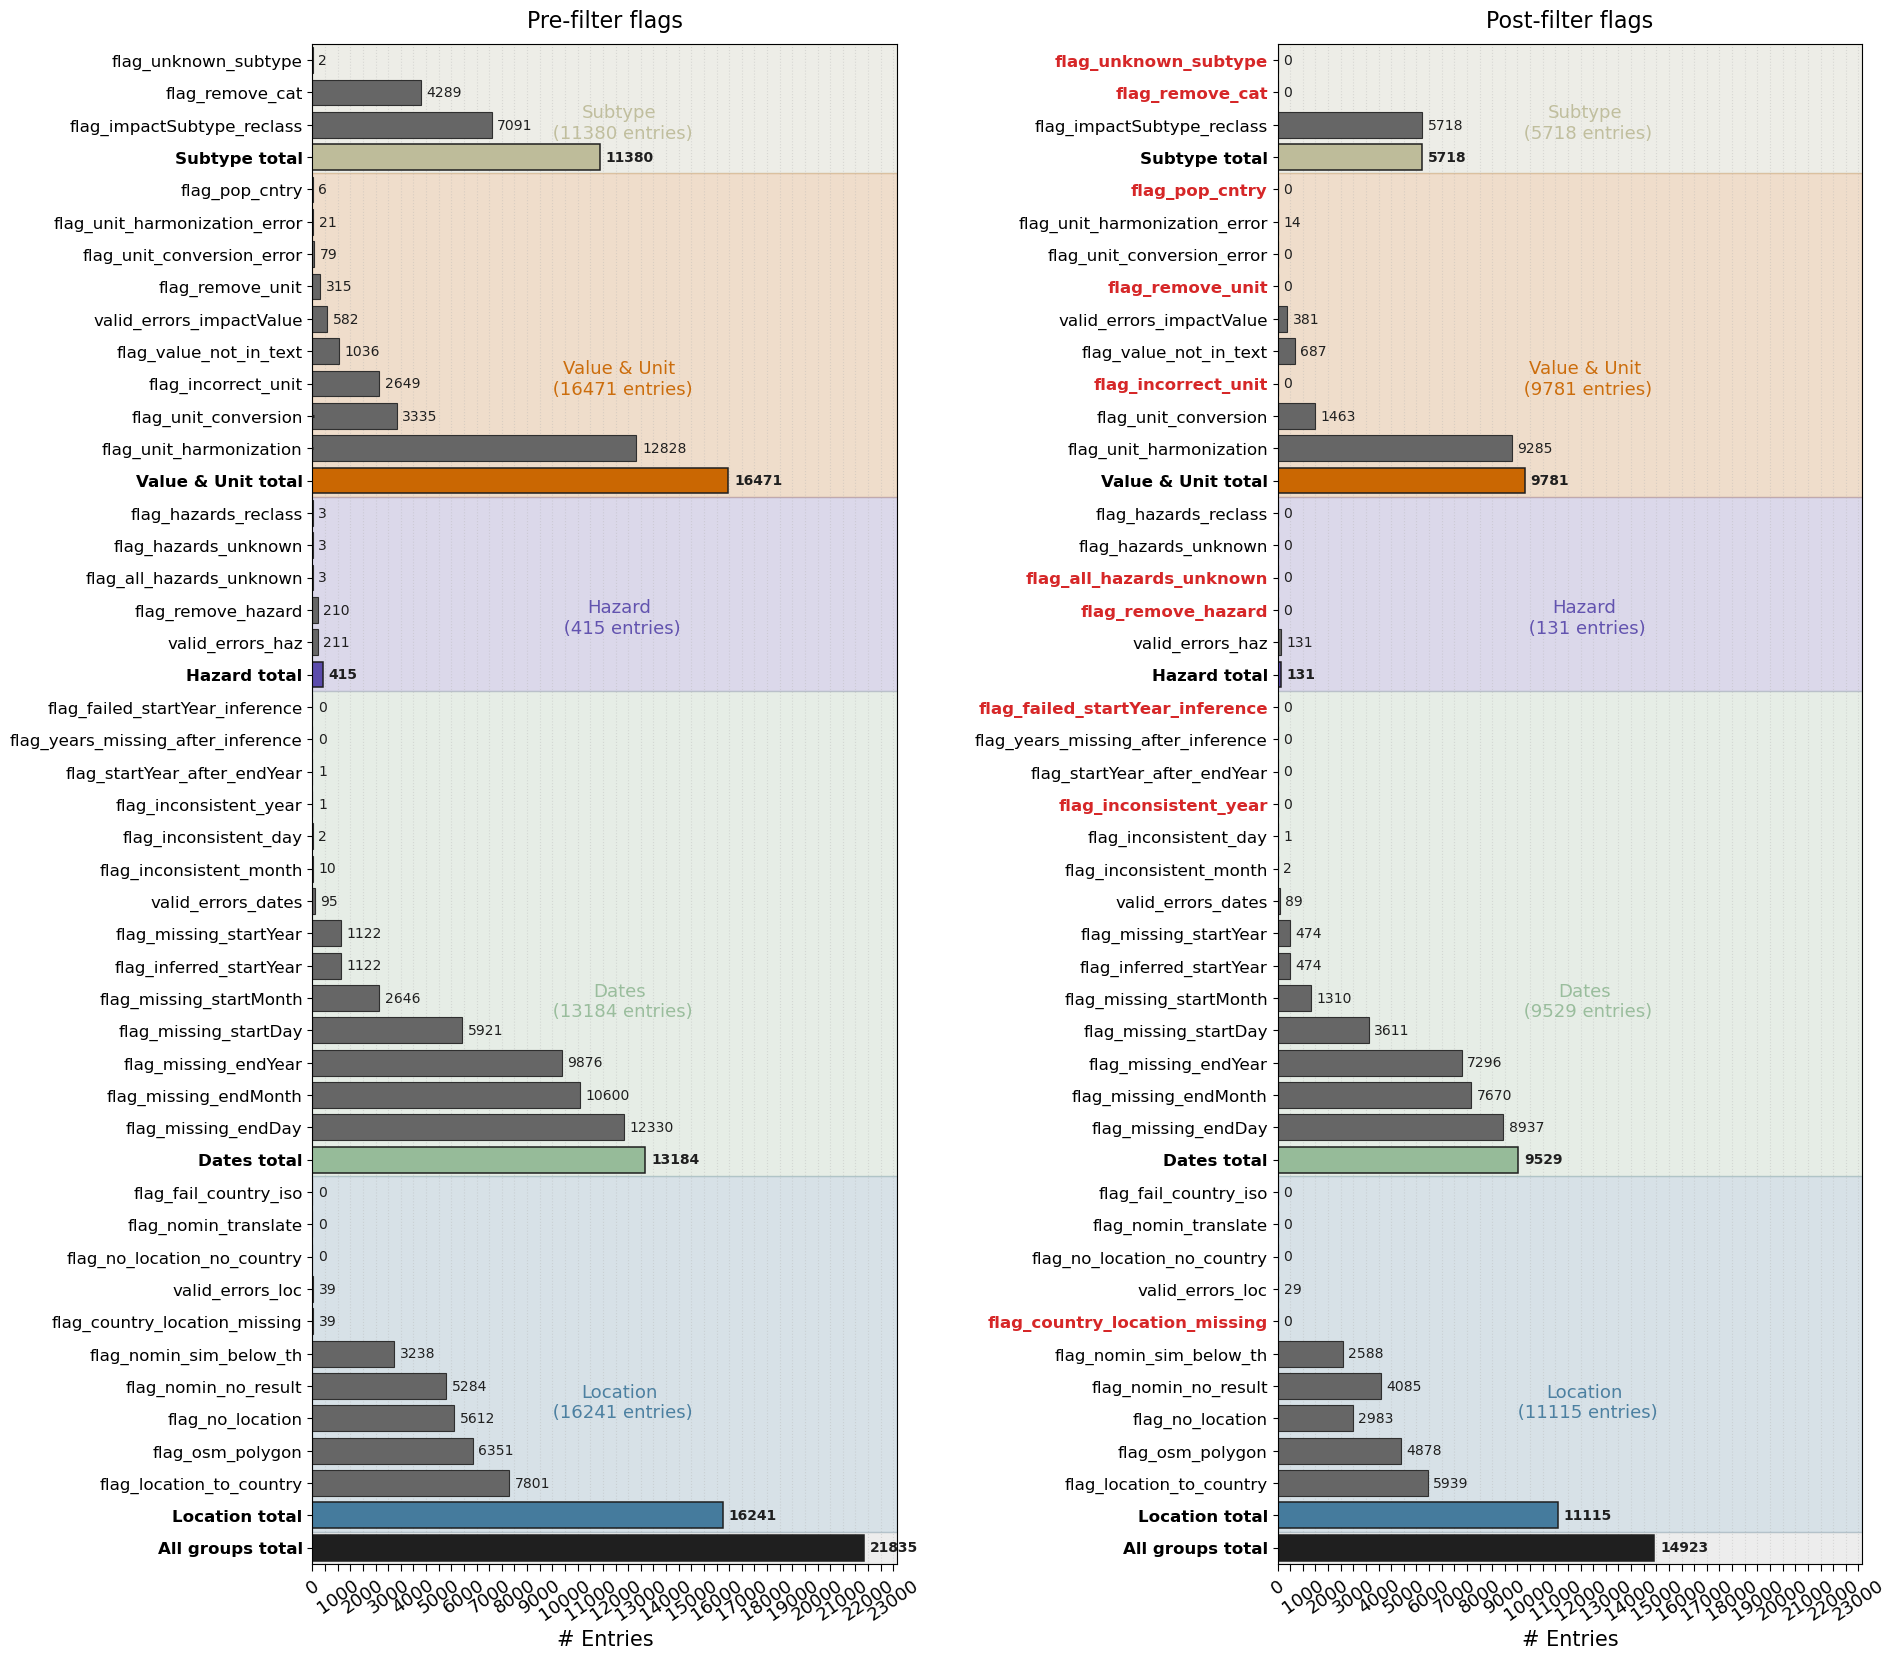

In [ ]:
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save = True
savename = "validation_flags_warnings_remove"

# -----------------------------------------------------------------------------
# Colors
# -----------------------------------------------------------------------------

category_palette = {
    "Subtype processing": "#bebc9a",
    "Subtype remove": "#bebc9a",
    "Value & Unit processing": "#ca6702",
    "Value & Unit qualitative conversion": "#ca6702",
    "Value & Unit remove": "#ca6702",
    "Hazard processing": "#5c4cac",
    "Hazard remove": "#5c4cac",
    "Dates processing": "#96bb99",
    "Dates remove": "#96bb99",
    "Location processing": "#457b9d",
    "Location remove": "#457b9d",
    "Other": "#999999",
}

domain_color_map = {
    "Subtype": category_palette["Subtype processing"],
    "Value & Unit": category_palette["Value & Unit processing"],
    "Hazard": category_palette["Hazard processing"],
    "Dates": category_palette["Dates processing"],
    "Location": category_palette["Location processing"],
}
unwanted_flag_color = "#d62728"
try:
    unwanted_flag_set = set(unwanted_flags)
except NameError:
    unwanted_flag_set = set()

# -----------------------------------------------------------------------------
# Use only the full dataframe
# -----------------------------------------------------------------------------
source_dict = results_dict
# source_df = results_dict["pre-filter"]
# source_df_filtered = results_dict["post-filter"]

# -----------------------------------------------------------------------------
# Pair warning and removal groups so the row height is shared by domain
# -----------------------------------------------------------------------------

# flag_group_pairs = [
#    ("Subtype", ["Subtype processing"], ["Subtype remove"]),
#    (
#        "Value & Unit",
#        ["Value & Unit processing"],
#        ["Value & Unit qualitative conversion", "Value & Unit remove"],
#    ),
#    ("Hazard", ["Hazard processing"], ["Hazard remove"]),
#    ("Dates", ["Dates processing"], ["Dates remove"]),
#    ("Location", ["Location processing"], ["Location remove"]),
# ]


def ordered_group_flags(flag_dict, group_names, df):
    ordered = []
    flag_to_category = {}
    spans = []

    for group_name in group_names:
        existing_flags = [
            flag for flag in flag_dict.get(group_name, []) if flag in df.columns
        ]

        if not existing_flags:
            continue

        group_counts = (
            df[existing_flags]
            .fillna(False)
            .astype(bool)
            .sum()
            .sort_values(ascending=True)
        )

        start = len(ordered)
        ordered.extend(group_counts.index.tolist())

        for flag in group_counts.index:
            flag_to_category[flag] = group_name

        end = len(ordered) - 1
        spans.append((group_name, start, end))

    return ordered, flag_to_category, spans


panel_data = {
    "Pre-filter flags": [],
    "Post-filter flags": [],
}
group_layout = []
y_start = 0

for domain_name, groups in flags_by_category.items():
    pre_flags_ordered, pre_flags_categories, pre_flags_spans = ordered_group_flags(
        flags_by_category, [domain_name], source_dict["pre-filter"]
    )

    post_flags_ordered, post_flags_categories, post_flags_spans = ordered_group_flags(
        flags_by_category, [domain_name], source_dict["post-filter"]
    )

    aligned_flags = list(dict.fromkeys(pre_flags_ordered + post_flags_ordered))
    aligned_categories = {
        flag: pre_flags_categories.get(flag, post_flags_categories.get(flag, domain_name))
        for flag in aligned_flags
    }

    if not aligned_flags:
        continue

    group_height = len(aligned_flags) + 1

    group_layout.append((domain_name, y_start, y_start + group_height - 1))

    panel_data["Pre-filter flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": aligned_flags,
            "flag_to_category": aligned_categories,
            "spans": pre_flags_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )
    panel_data["Post-filter flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": aligned_flags,
            "flag_to_category": aligned_categories,
            "spans": post_flags_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )

    y_start += group_height

all_total_y = y_start
total_y_rows = y_start + 1
all_ordered_flags = [
    flag
    for panel_groups in panel_data.values()
    for group in panel_groups
    for flag in group["ordered_flags"]
]

# -----------------------------------------------------------------------------
# Counts and figure setup
# -----------------------------------------------------------------------------

panel_sources = {
    "Pre-filter flags": source_dict["pre-filter"],
    "Post-filter flags": source_dict["post-filter"],
}
unique_ordered_flags = pd.Index(all_ordered_flags).unique()
flag_counts_by_panel = {
    panel_title: pd.Series(
        [int(panel_df[flag].fillna(False).astype(bool).sum()) for flag in unique_ordered_flags if flag in panel_df.columns],
        index=[flag for flag in unique_ordered_flags if flag in panel_df.columns],
        dtype=int,
    )
    for panel_title, panel_df in panel_sources.items()
}
add_total_rows = False
total_rows = max(len(panel_df) for panel_df in panel_sources.values())
label = "total number of rows with at least one flag"
all_total_counts = {}
for panel_title, panel_df in panel_sources.items():
    panel_total_flags = [flag for flag in unique_ordered_flags if flag in panel_df.columns]
    all_total_counts[panel_title] = int(
        panel_df[panel_total_flags].fillna(False).astype(bool).any(axis=1).sum()
    ) if panel_total_flags else 0
max_flag_count = max((counts.max() for counts in flag_counts_by_panel.values() if len(counts)), default=0)
max_total_count = max(all_total_counts.values(), default=0)
max_x = max(total_rows, max_flag_count, max_total_count)
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)
fig_height = max(5.5, 0.42 * total_y_rows)

fig, axes = plt.subplots(
    ncols=2,
    figsize=(20, fig_height),
    gridspec_kw={"wspace": 0.65},
)

for ax, (panel_title, panel_groups) in zip(axes, panel_data.items()):
    is_right_panel = ax is axes[1]
    panel_df = panel_sources[panel_title]
    flag_counts = flag_counts_by_panel[panel_title]
    ax.set_axisbelow(True)

    # -------------------------------------------------------------------------
    # Shared domain shading
    # -------------------------------------------------------------------------

    for domain_name, start, end in group_layout:
        ax.axhspan(
            start - 0.5,
            end + 0.5,
            color="#d9d9d9",
            alpha=0.16,
            zorder=0,
        )
    ax.axhspan(
        all_total_y - 0.5,
        all_total_y + 0.5,
        color="#1f1f1f",
        alpha=0.08,
        zorder=0,
    )

    # -------------------------------------------------------------------------
    # Side-specific group labels, bars, value labels, and error overlays
    # -------------------------------------------------------------------------

    for group in panel_groups:
        y_offset = group["y_offset"]
        ordered_flags = group["ordered_flags"]
        flag_to_category = group["flag_to_category"]
        domain_start = group["y_offset"]
        domain_end = domain_start + group["group_height"] - 1

        domain_color = domain_color_map[group["domain"]]

        panel_ordered_flags = [flag for flag in ordered_flags if flag in panel_df.columns]
        group_total = int(
            panel_df[panel_ordered_flags].fillna(False).astype(bool).any(axis=1).sum()
        ) if panel_ordered_flags else 0

        ax.axhspan(
            domain_start - 0.5,
            domain_end + 0.5,
            color=domain_color,
            alpha=0.18,
            zorder=0.2,
        )

        ax.text(
            x_max * 0.525,
            domain_start + (domain_end - domain_start) * 0.65,
            f"{group['domain']}\n ({group_total} entries)",
            ha="center",
            va="center",
            fontsize=13,
            color=domain_color,
            alpha=0.95,
            zorder=1.5,
        )

        y_positions = y_offset + np.arange(len(ordered_flags))
        counts = flag_counts.reindex(ordered_flags).fillna(0).astype(int)
        bar_colors = [
            unwanted_flag_color
            if is_right_panel and flag in unwanted_flag_set
            else category_palette.get(flag_to_category.get(flag, "Other"), "#666666")
            for flag in ordered_flags
        ]

        ax.barh(
            y_positions,
            counts.values,
            color=bar_colors,
            edgecolor="#2f2f2f",
            linewidth=0.8,
            zorder=2,
        )

        for y_pos, flag_name, flag_count in zip(
            y_positions,
            ordered_flags,
            counts.values,
        ):
            ax.annotate(
                f"{flag_count}",
                xy=(flag_count, y_pos),
                xytext=(4, 0),
                textcoords="offset points",
                va="center",
                ha="left",
                fontsize=10,
                color="#1f1f1f",
                zorder=4,
            )

            error_col = f"{flag_name}_error"

            if error_col in panel_df.columns:
                error_count = int(panel_df[error_col].fillna(False).astype(bool).sum())

                if error_count > 0:
                    ax.hlines(
                        y_pos,
                        0,
                        min(error_count, flag_count),
                        colors="#1f1f1f",
                        linestyles="--",
                        linewidth=2.2,
                        zorder=3,
                    )

        total_y = y_offset + len(ordered_flags)
        ax.barh(
            total_y,
            group_total,
            color=domain_color,
            edgecolor="#1f1f1f",
            linewidth=1.1,
            zorder=2.5,
        )
        ax.annotate(
            f"{group_total}",
            xy=(group_total, total_y),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
            color="#1f1f1f",
            zorder=4,
        )

    all_total_count = all_total_counts[panel_title]
    ax.barh(
        all_total_y,
        all_total_count,
        color="#1f1f1f",
        edgecolor="#1f1f1f",
        linewidth=1.1,
        zorder=2.5,
    )
    ax.annotate(
        f"{all_total_count}",
        xy=(all_total_count, all_total_y),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#1f1f1f",
        zorder=4,
    )

    # -------------------------------------------------------------------------
    # Total rows reference line and styling
    # -------------------------------------------------------------------------

    if add_total_rows:
        for _, start, end in group_layout:
            ax.vlines(
                total_rows,
                start - 0.5,
                end + 0.5,
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                zorder=4,
            )

    ax.set_title(panel_title, fontsize=16, pad=12)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])
    ax.tick_params(axis="x", which="major", length=5, labelrotation=35, labelsize=13)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("# Entries", fontsize=15)
    ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

y_labels = [""] * total_y_rows
for group in panel_data["Pre-filter flags"]:
    for idx, flag in enumerate(group["ordered_flags"]):
        y_labels[group["y_offset"] + idx] = flag
    y_labels[group["y_offset"] + len(group["ordered_flags"])] = f"{group['domain']} total"
y_labels[all_total_y] = "All groups total"

for i, ax in enumerate(axes):
    ax.set_yticks(np.arange(total_y_rows))
    ax.set_yticklabels(y_labels, fontsize=12)

    ax.set_ylim(total_y_rows - 0.5, -0.5)
    for label in ax.get_yticklabels():
        if label.get_text() in unwanted_flag_set and i == 1:  # Only apply to the right panel
            label.set_color(unwanted_flag_color)
            label.set_fontweight("bold")
        elif "total" in label.get_text():
            label.set_fontweight("bold")


if add_total_rows:
    axes[1].legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                label=f"{label} ({total_rows})",
            ),
        ],
        fontsize=12,
        loc="lower right",
        frameon=True,
    )

plt.tight_layout()
plt.show()

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(
        os.path.join(path_save_fig, f"{savename}.png"), dpi=300, bbox_inches="tight"
    )

In [ ]:
dict_flag_name_plot = {
    "flag_value_not_in_text" : "Value not in text",
    "flag_percent" : "Unit Percentage",
    "flag_unit_not_in_text" : "Unit not in text",
    "flag_value_no_unit" : "Value without unit",
    "flag_incorrect_unit" : "Incorrect unit",
    "flag_unit_correction" : "Unit corrected",
}

In [ ]:
## Validation
flags_valid_error = [
    "valid_errors_impactValue",
    "valid_errors_loc",
    "valid_errors_haz",
    "valid_errors_dates",
]
## Value
flags_quanti_value_error = ["flag_value_not_in_text", "flag_pop_cntry"]

## Unit
# flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_partial_unit", "flag_unit_nonstd", "flag_percent"]
flags_quanti_unit = ["flag_unit_not_in_text", "flag_value_no_unit", "flag_unit_incorrect_unit"]

flags_quanti_unit_correction = ["flag_remove_number_unit", "flag_unit_harmonization", "flag_unit_conversion",
                                "flag_SI_unit_standardization", "flag_non-SI_unit_standardization",
                                "flag_people_unit_normalization", "flag_currency_conversion"]

flags_subtypes = ["flag_impactSubtype_reclass", "flag_unknown_subtype", "flag_reclass_subtype_from_unit", "flag_impactSubtype_merged", "flag_response_unit"]
flags_hazard = ["flag_hazards_reclass", "flag_hazards_unknown"]
# flags_coherence = ["flag_pop_cntry"]
flags_remove = [
    "flag_remove_cat",
    "flag_remove_hazard",
    "flag_remove_unit",
    "flag_response_unit",
]

In [ ]:
# separate between processing/warning flags and flags that remove rows
warning_flags = {
    "Subtype processing": [
        "valid_errors_impactSubtype",
        "flag_impactSubtype_reclass",
        "flag_reclass_subtype_from_unit",
        "flag_impactSubtype_merged",
    ],
    "Value & Unit processing": [
        "valid_errors_impactValue",
        "flag_remove_number_unit",
        "flag_unit_harmonization",
        "flag_unit_conversion",
        "flag_SI_unit_standardization",
        "flag_non-SI_unit_standardization",
        "flag_people_unit_normalization",
        "flag_currency_conversion",
        "flag_unit_conversion"
        "flag_percent",
        "flag_unit_nonstd",
    ],
    "Hazard processing": [
        "valid_errors_haz",
        "flag_hazards_reclass",
        "flag_hazards_unknown",
        # "flag_remove_hazard",
    ],
    "Dates processing": [
        "valid_errors_dates",
        "flag_missing_startYear",
        "flag_missing_endYear",
        "flag_missing_startMonth",
        "flag_missing_endMonth",
        "flag_missing_startDay",
        "flag_missing_endDay",
        "flag_startYear_after_endYear",
        "flag_inconsistent_year",
        "flag_inconsistent_month",
        "flag_inconsistent_day",
        "flag_inferred_startYear",
        "flag_failed_startYear_inference",
    ],
    "Location processing": [
        "valid_errors_loc",
        # "flag_geocoding_country",
        # "flag_geocoding_osm",
        "flag_location_to_country",
        "flag_osm_polygon",
        "flag_no_location",
        "flag_nomin_no_result",
        "flag_nomin_sim_below_th",
        "flag_nomin_translate",
    ],
}

remove_flags = {
    "Subtype remove": [
        "flag_unknown_subtype",
        "flag_remove_cat",
    ],
    "Value & Unit qualitative conversion": [
        "flag_value_no_unit",
        "flag_partial_unit",
    ],
    "Value & Unit remove": [
        "flag_value_not_in_text",
        "flag_unit_conversion_error",
        "flag_pop_cntry",
        "flag_remove_number_unit_error",
        "flag_SI_unit_standardization_error",
        "flag_non-SI_unit_standardization_error",
        "flag_unit_harmonization_error",
        "flag_currency_conversion_error",
        "flag_remove_unit",
        "flag_response_unit",
    ],
    "Hazard remove": [
        "flag_all_hazards_unknown",
    ],
    "Dates remove": [
        "flag_years_missing",
    ],
    "Location remove": [
        "flag_country_location_missing",
    ],
}

all_flags = {
    "Subtype processing": warning_flags["Subtype processing"],
    "Subtype remove": remove_flags["Subtype remove"],
    "Value & Unit processing": warning_flags["Value & Unit processing"],
    "Value & Unit qualitative conversion": remove_flags["Value & Unit qualitative conversion"],
    "Value & Unit remove": remove_flags["Value & Unit remove"],
    "Hazard processing": warning_flags["Hazard processing"],
    "Hazard remove": remove_flags["Hazard remove"],
    "Dates processing": warning_flags["Dates processing"],
    "Dates remove": remove_flags["Dates remove"],
    "Location processing": warning_flags["Location processing"],
    "Location remove": remove_flags["Location remove"],
}


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_84180/2536490394.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_84180/2536490394.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_84180/2536490394.py:153: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the

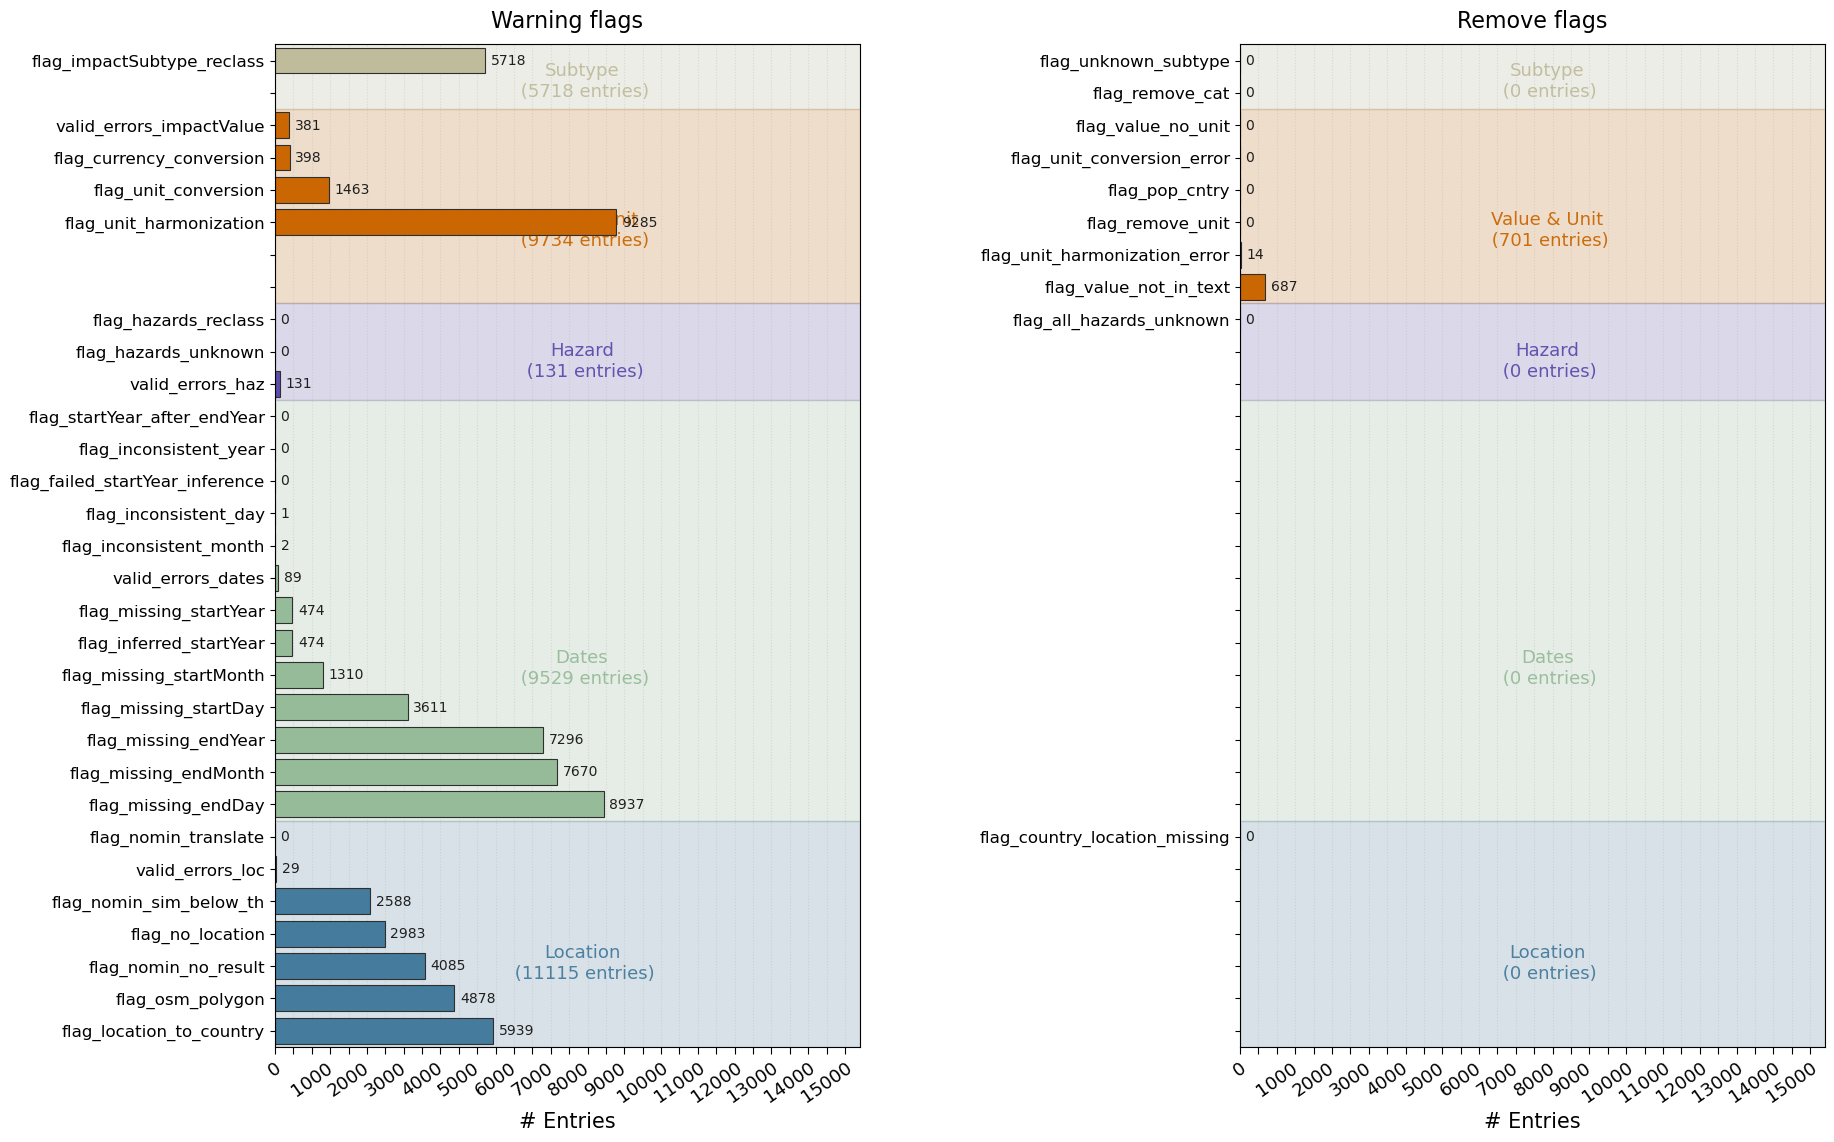

In [ ]:



from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save = False
savename = "validation_flags_warnings_remove"

# -----------------------------------------------------------------------------
# Colors
# -----------------------------------------------------------------------------

category_palette = {
    "Subtype processing": "#bebc9a",
    "Subtype remove": "#bebc9a",
    "Value & Unit processing": "#ca6702",
    "Value & Unit qualitative conversion": "#ca6702",
    "Value & Unit remove": "#ca6702",
    "Hazard processing": "#5c4cac",
    "Hazard remove": "#5c4cac",
    "Dates processing": "#96bb99",
    "Dates remove": "#96bb99",
    "Location processing": "#457b9d",
    "Location remove": "#457b9d",
    "Other": "#999999",
}

domain_color_map = {
    "Subtype": category_palette["Subtype processing"],
    "Value & Unit": category_palette["Value & Unit processing"],
    "Hazard": category_palette["Hazard processing"],
    "Dates": category_palette["Dates processing"],
    "Location": category_palette["Location processing"],
}

# -----------------------------------------------------------------------------
# Use only the full dataframe
# -----------------------------------------------------------------------------

source_df = df

# -----------------------------------------------------------------------------
# Pair warning and removal groups so the row height is shared by domain
# -----------------------------------------------------------------------------

flag_group_pairs = [
    ("Subtype", ["Subtype processing"], ["Subtype remove"]),
    (
        "Value & Unit",
        ["Value & Unit processing"],
        ["Value & Unit qualitative conversion", "Value & Unit remove"],
    ),
    ("Hazard", ["Hazard processing"], ["Hazard remove"]),
    ("Dates", ["Dates processing"], ["Dates remove"]),
    ("Location", ["Location processing"], ["Location remove"]),
]


def ordered_group_flags(flag_dict, group_names):
    ordered = []
    flag_to_category = {}
    spans = []

    for group_name in group_names:
        existing_flags = [
            flag for flag in flag_dict.get(group_name, []) if flag in source_df.columns
        ]

        if not existing_flags:
            continue

        group_counts = (
            source_df[existing_flags]
            .fillna(False)
            .astype(bool)
            .sum()
            .sort_values(ascending=True)
        )

        start = len(ordered)
        ordered.extend(group_counts.index.tolist())

        for flag in group_counts.index:
            flag_to_category[flag] = group_name

        end = len(ordered) - 1
        spans.append((group_name, start, end))

    return ordered, flag_to_category, spans


panel_data = {
    "Warning flags": [],
    "Remove flags": [],
}
group_layout = []
y_start = 0

for domain_name, warning_groups, remove_groups in flag_group_pairs:
    warning_ordered, warning_categories, warning_spans = ordered_group_flags(
        warning_flags,
        warning_groups,
    )
    remove_ordered, remove_categories, remove_spans = ordered_group_flags(
        remove_flags,
        remove_groups,
    )

    group_height = max(len(warning_ordered), len(remove_ordered))

    if group_height == 0:
        continue

    group_layout.append((domain_name, y_start, y_start + group_height - 1))

    panel_data["Warning flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": warning_ordered,
            "flag_to_category": warning_categories,
            "spans": warning_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )
    panel_data["Remove flags"].append(
        {
            "domain": domain_name,
            "ordered_flags": remove_ordered,
            "flag_to_category": remove_categories,
            "spans": remove_spans,
            "y_offset": y_start,
            "group_height": group_height,
        }
    )

    y_start += group_height

total_y_rows = y_start
all_ordered_flags = [
    flag
    for panel_groups in panel_data.values()
    for group in panel_groups
    for flag in group["ordered_flags"]
]

# -----------------------------------------------------------------------------
# Counts and figure setup
# -----------------------------------------------------------------------------

unique_ordered_flags = pd.Index(all_ordered_flags).unique()
flag_counts = pd.Series(
    [int(source_df[flag].fillna(False).astype(bool).sum()) for flag in unique_ordered_flags],
    index=unique_ordered_flags,
    dtype=int,
)
add_total_rows = False
total_rows = len(
    source_df
)  # len(source_df[source_df[all_ordered_flags].any(axis=1)].dropna(how="all"))
label = "total number of rows with at least one flag"
max_x = max(total_rows, flag_counts.max())
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)
fig_height = max(5.5, 0.42 * total_y_rows)

fig, axes = plt.subplots(
    ncols=2,
    figsize=(20, fig_height),
    gridspec_kw={"wspace": 0.65},
)

for ax, (panel_title, panel_groups) in zip(axes, panel_data.items()):
    ax.set_axisbelow(True)

    # -------------------------------------------------------------------------
    # Shared domain shading
    # -------------------------------------------------------------------------

    for domain_name, start, end in group_layout:
        ax.axhspan(
            start - 0.5,
            end + 0.5,
            color="#d9d9d9",
            alpha=0.16,
            zorder=0,
        )

    # -------------------------------------------------------------------------
    # Side-specific group labels, bars, value labels, and error overlays
    # -------------------------------------------------------------------------

    for group in panel_groups:
        y_offset = group["y_offset"]
        ordered_flags = group["ordered_flags"]
        flag_to_category = group["flag_to_category"]
        domain_start = group["y_offset"]
        domain_end = domain_start + group["group_height"] - 1

        domain_color = domain_color_map[group["domain"]]

        group_total = len(
            source_df[source_df[ordered_flags].any(axis=1)].dropna(how="all")
        )

        ax.axhspan(
            domain_start - 0.5,
            domain_end + 0.5,
            color=domain_color,
            alpha=0.18,
            zorder=0.2,
        )

        ax.text(
            x_max * 0.525,
            domain_start + (domain_end - domain_start) *0.65,
            f"{group['domain']}\n ({group_total} entries)",
            ha="center",
            va="center",
            fontsize=13,
            color=domain_color,
            alpha=0.95,
            zorder=1.5,
        )

        y_positions = y_offset + np.arange(len(ordered_flags))
        counts = flag_counts.reindex(ordered_flags).fillna(0).astype(int)
        bar_colors = [
            category_palette.get(flag_to_category.get(flag, "Other"), "#666666")
            for flag in ordered_flags
        ]

        ax.barh(
            y_positions,
            counts.values,
            color=bar_colors,
            edgecolor="#2f2f2f",
            linewidth=0.8,
            zorder=2,
        )

        for y_pos, flag_name, flag_count in zip(
            y_positions,
            ordered_flags,
            counts.values,
        ):
            ax.annotate(
                f"{flag_count}",
                xy=(flag_count, y_pos),
                xytext=(4, 0),
                textcoords="offset points",
                va="center",
                ha="left",
                fontsize=10,
                color="#1f1f1f",
                zorder=4,
            )

            error_col = f"{flag_name}_error"

            if error_col in source_df.columns:
                error_count = int(source_df[error_col].fillna(False).astype(bool).sum())

                if error_count > 0:
                    ax.hlines(
                        y_pos,
                        0,
                        min(error_count, flag_count),
                        colors="#1f1f1f",
                        linestyles="--",
                        linewidth=2.2,
                        zorder=3,
                    )

    # -------------------------------------------------------------------------
    # Total rows reference line and styling
    # -------------------------------------------------------------------------

    if add_total_rows:
        for _, start, end in group_layout:
            ax.vlines(
                total_rows,
                start - 0.5,
                end + 0.5,
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                zorder=4,
            )

    ax.set_title(panel_title, fontsize=16, pad=12)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(tick) if tick % 1000 == 0 else "" for tick in x_ticks])
    ax.tick_params(axis="x", which="major", length=5, labelrotation=35, labelsize=13)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("# Entries", fontsize=15)
    ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

axes[0].set_yticks(np.arange(total_y_rows))
axes[0].set_yticklabels(
    [
        next(
            (
                flag
                for group in panel_data["Warning flags"]
                for idx, flag in enumerate(group["ordered_flags"])
                if group["y_offset"] + idx == y_pos
            ),
            "",
        )
        for y_pos in range(total_y_rows)
    ],
    fontsize=12,
)
axes[1].set_yticks(np.arange(total_y_rows))
axes[1].set_yticklabels(
    [
        next(
            (
                flag
                for group in panel_data["Remove flags"]
                for idx, flag in enumerate(group["ordered_flags"])
                if group["y_offset"] + idx == y_pos
            ),
            "",
        )
        for y_pos in range(total_y_rows)
    ],
    fontsize=12,
)
for ax in axes:
    ax.set_ylim(total_y_rows - 0.5, -0.5)

if add_total_rows:
    axes[1].legend(
        handles=[
            Line2D(
                [0],
                [0],
                color="#1f1f1f",
                linestyle="--",
                linewidth=2.2,
                label=f"{label} ({total_rows})",
            ),
        ],
        fontsize=12,
        loc="lower right",
        frameon=True,
    )

plt.tight_layout()
plt.show()

if save:
    os.makedirs(path_save_fig, exist_ok=True)
    fig.savefig(os.path.join(path_save_fig, f"{savename}.png"), dpi=300, bbox_inches="tight")

In [ ]:
flag_counts

flag_impactSubtype_reclass         5718
valid_errors_impactValue            381
flag_currency_conversion            398
flag_unit_conversion               1463
flag_unit_harmonization            9285
flag_hazards_reclass                  0
flag_hazards_unknown                  0
valid_errors_haz                    131
flag_startYear_after_endYear          0
flag_inconsistent_year                0
flag_failed_startYear_inference       0
flag_inconsistent_day                 1
flag_inconsistent_month               2
valid_errors_dates                   89
flag_missing_startYear              474
flag_inferred_startYear             474
flag_missing_startMonth            1310
flag_missing_startDay              3611
flag_missing_endYear               7296
flag_missing_endMonth              7670
flag_missing_endDay                8937
flag_nomin_translate                  0
valid_errors_loc                     29
flag_nomin_sim_below_th            2588
flag_no_location                   2983


In [ ]:
domain_start

24

In [ ]:
domain_end

30

In [ ]:
# The quanti rows are the rows with a value in the impactValue column
df_llm_all_geo_quanti = df_llm_all_geo[df_llm_all_geo["impactValue"].notna()].copy()


NameError: name 'df_llm_all_geo' is not defined

valid_errors_loc 33
valid_errors_dates 83
valid_errors_haz 212
valid_errors_impactValue 415
flag_pop_cntry 7
flag_value_not_in_text 834
flag_value_no_unit 0
flag_unit_conversion 2582
flag_unit_harmonization 9915
flag_impactSubtype_reclass 25
flag_unknown_subtype 32
flag_response_unit 120
flag_reclass_subtype_from_unit 314
flag_impactSubtype_merged 5786
flag_hazards_unknown 4
flag_hazards_reclass 5
flag_remove_unit 105
flag_response_unit 120
flag_remove_hazard 217
flag_remove_cat 3334
flag_unit_conversion_error 51
flag_unit_harmonization_error 73


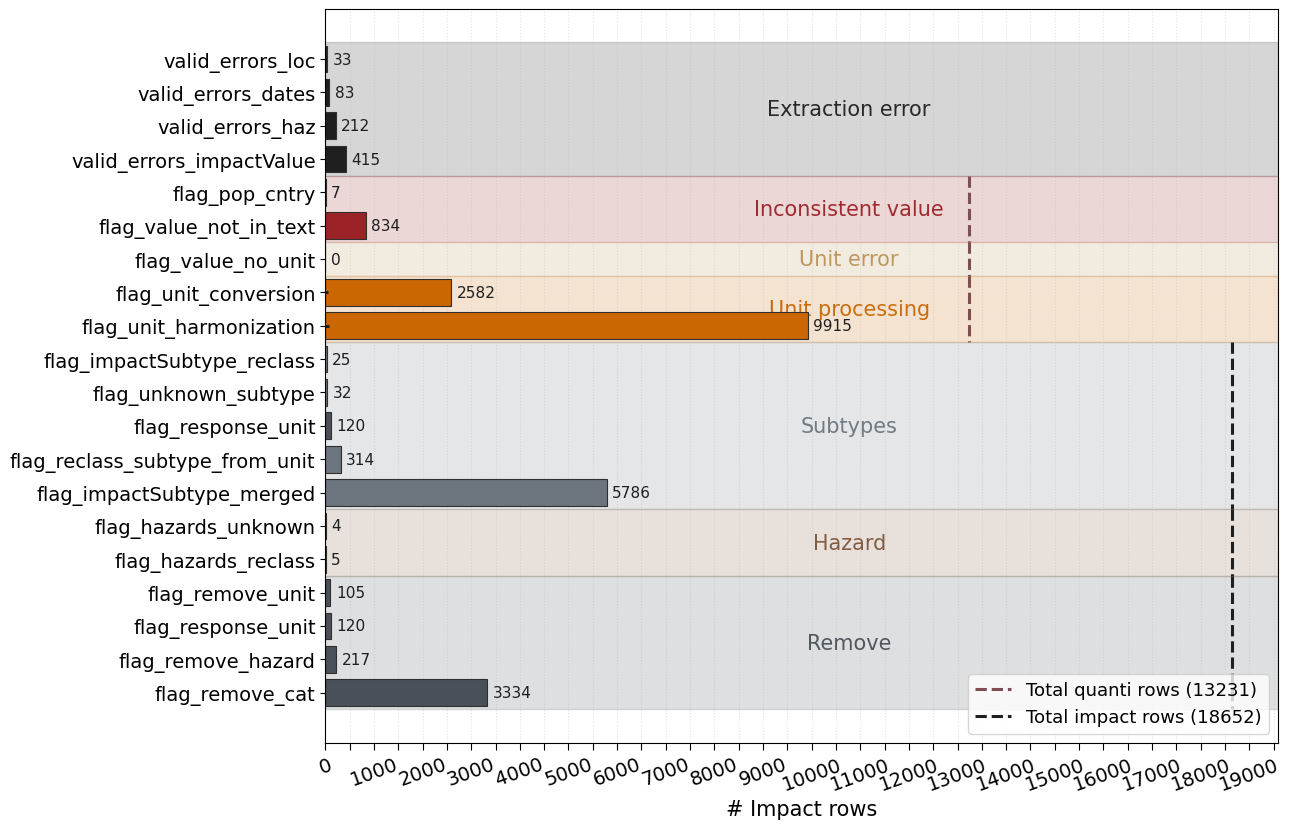

In [ ]:
flag_groups = [
    ("Extraction error", flags_valid_error),
    ("Inconsistent value", flags_quanti_value_error),
    ("Unit error", flags_quanti_unit),
    ("Unit processing", flags_quanti_unit_correction),
    ("Subtypes", flags_subtypes),
    ("Hazard", flags_hazard),
    #("Coherence", flags_coherence),
    ("Remove", flags_remove),
]
category_palette = {
    "Extraction error": "#1f1f1f",
    "Inconsistent value": "#9b2226",
    "Unit error": "#bb9457",
    "Unit processing": "#ca6702",
    #"Remove quanti": "#7d4f50",
    "Subtypes": "#6c757d",
    "Hazard": "#7f5539",
    #"Coherence": "#adb5bd",
    "Remove": "#495057",
}

quanti_groups = {"Inconsistent value", "Unit error", "Unit processing", "Remove quanti"}
other_groups = {"Subtypes", "Hazard", "Coherence", "Remove"}

# Keep the group order used in the notebook and add any remaining flags at the end.
known_flags = {flag for _, group in flag_groups for flag in group}
base_flags = [flag for flag in flag_cols ]#if not flag.endswith("_error")]
remaining_flags = [flag for flag in base_flags if flag not in known_flags]

ordered_flags = []
category_spans = []
flag_to_category = {}
for group_index, (group_name, group_flags) in enumerate(flag_groups):
    existing_flags = [flag for flag in group_flags if flag in base_flags]
    if not existing_flags:
        continue
    source_df = df_llm_all_geo_quanti if group_name in quanti_groups else df_llm_all_geo
    group_counts = (
        source_df[existing_flags]
        .fillna(False)
        .astype(bool)
        .sum()
        .sort_values(ascending=True)
    )
    start = len(ordered_flags)
    ordered_flags.extend(group_counts.index.tolist())
    for flag in group_counts.index.tolist():
        flag_to_category[flag] = group_name
    end = len(ordered_flags) - 1
    category_spans.append((group_name, start, end, group_index))

flag_counts = []
for flag in ordered_flags:
    group_name = flag_to_category.get(flag, "")
    source_df = df_llm_all_geo_quanti if group_name in quanti_groups else df_llm_all_geo
    print(flag, source_df[flag].fillna(False).astype(bool).sum())
    flag_counts.append(int(source_df[flag].fillna(False).astype(bool).sum()))
flag_counts = pd.Series(flag_counts, index=ordered_flags, dtype=int)

bar_colors = [category_palette.get(flag_to_category.get(flag, ""), "#666666") for flag in ordered_flags]

total_impact_rows = len(df_llm_all_geo)
total_quanti_rows = len(df_llm_all_geo_quanti)
max_x = int(max(total_impact_rows, total_quanti_rows, flag_counts.max())) if len(flag_counts) else max(total_impact_rows, total_quanti_rows)
x_padding = max(2, int(np.ceil(max_x * 0.05)))
x_max = max_x + x_padding
x_tick_step = 500
x_ticks = np.arange(0, x_max + x_tick_step, x_tick_step)

fig_height = max(5.5, 0.42 * len(ordered_flags))
fig, ax = plt.subplots(figsize=(13, fig_height))
ax.set_axisbelow(True)

for group_name, start, end, _ in category_spans:
    ax.axhspan(
        start - 0.5,
        end + 0.5,
        color=category_palette.get(group_name, "#d9d9d9"),
        alpha=0.18,
        zorder=0,
    )

label_x = x_max * 0.55
for group_name, start, end, _ in category_spans:
    ax.text(
        label_x,
        (start + end) / 2,
        group_name,
        ha="center",
        va="center",
        fontsize=15,
        color=category_palette.get(group_name, "#1f1f1f"),
        alpha=0.95,
        zorder=1.5,
    )

y_positions = np.arange(len(ordered_flags))
ax.barh(y_positions, flag_counts.values, color=bar_colors, edgecolor="#2f2f2f", linewidth=0.8, zorder=2)

for y_pos, flag_name, flag_count in zip(y_positions, ordered_flags, flag_counts.values):
    ax.annotate(
        f"{int(flag_count)}",
        xy=(flag_count, y_pos),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=11,
        color="#1f1f1f",
        zorder=4,
    )
    error_col = f"{flag_name}_error"
    if error_col in df_llm_all_geo.columns:
        source_df = df_llm_all_geo_quanti if flag_to_category.get(flag_name, "") in quanti_groups else df_llm_all_geo
        error_count = int(source_df[error_col].fillna(False).astype(bool).sum())
        print(error_col, error_count)
        if error_count > 0:
            ax.hlines(
                y_pos,
                0,
                min(error_count, flag_count),
                colors="#1f1f1f",
                linestyles="--",
                linewidth=2.2,
                zorder=3,
            )

for group_name, start, end, _ in category_spans:
    if group_name in quanti_groups:
        ax.vlines(
            total_quanti_rows,
            start - 0.5,
            end + 0.5,
            color="#7d4f50",
            linestyle="--",
            linewidth=2.2,
            zorder=4,
        )
    elif group_name in other_groups:
        ax.vlines(
            total_impact_rows,
            start - 0.5,
            end + 0.5,
            color="#1f1f1f",
            linestyle="--",
            linewidth=2.2,
            zorder=4,
        )

ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{tick}" if tick % 1000 == 0 else "" for tick in x_ticks])
ax.tick_params(axis="x", which="major", length=5, labelrotation=20, labelsize=14)
ax.set_xlim(0, x_max)
ax.set_yticks(y_positions)
ax.set_yticklabels(ordered_flags, fontsize=14)
ax.set_xlabel("# Impact rows", fontsize=15)
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.35, zorder=1)

ax.legend(handles=[
    Line2D([0], [0], color="#7d4f50", linestyle="--", linewidth=2.2, label=f"Total quanti rows ({total_quanti_rows})"),
    Line2D([0], [0], color="#1f1f1f", linestyle="--", linewidth=2.2, label=f"Total impact rows ({total_impact_rows})"),
], fontsize=13, loc="lower right", frameon=True)

plt.tight_layout()
#fig.savefig(path_save_fig / "flags.png", transparent=True, bbox_inches='tight', dpi=300)
#fig.savefig(path_save_fig / "flags.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
#fig.savefig(path_save_fig / "flags.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

# Geocoding 

In [ ]:
nominatim_output = pd.read_pickle(DATA_OUT_PROC / "nominatim_output_220526.pkl")
geocoding_unique = gpd.read_file(DATA_OUT_PROC / "geocode_unique_220526.gpkg")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/lseverino/Documents/PhD/Projects/Como/Data_backup/results_proc/nominatim_output_220526.pkl'

In [ ]:
geocoding_unique.location.nunique()

8898

In [ ]:
# Aggregate per unique location so repeated split rows count as one location.
existing_flag_cols = [flag for flag in flag_cols if flag in geocoding_unique.columns]
grouped_locations = geocoding_unique.groupby("location", dropna=False)

location_summary = grouped_locations.agg(
    finest_level=("finest_level", lambda s: pd.to_numeric(s, errors="coerce").max()),
).reset_index()
for flag in existing_flag_cols:
    location_summary[flag] = grouped_locations[flag].apply(
        lambda s: int(pd.to_numeric(s, errors="coerce").fillna(0).astype(bool).all())
    ).to_numpy()

location_summary["flag_count"] = location_summary[existing_flag_cols].sum(axis=1) if existing_flag_cols else 0
location_summary

,location,finest_level,flag_geocoding_country,flag_geocoding_osm,flag_count
0,'Eua,1.0,0,0,0
1,1 de Diciembre,2.0,0,0,0
2,"1,144 villages",0.0,1,0,1
3,"1,208 villages across 106 districts in 15 prov...",0.0,1,0,1
4,"1,215 barangays",2.0,0,1,1
...,...,...,...,...,...
8893,Đurđevik,2.0,0,1,1
8894,Šabac,2.0,0,0,0
8895,Žitorađa,0.0,1,0,1
8896,Živinice,2.0,0,1,1


In [ ]:
location_summary.finest_level.value_counts().sort_index()

finest_level
0.0    3248
1.0    2439
2.0    3207
Name: count, dtype: int64

In [ ]:
location_summary.groupby("finest_level")["flag_geocoding_country"].sum().sort_index()

finest_level
0.0    3127
1.0       0
2.0       0
Name: flag_geocoding_country, dtype: int64

In [ ]:
location_summary.groupby("finest_level")["flag_geocoding_osm"].sum().sort_index()

finest_level
0.0       0
1.0     448
2.0    1337
Name: flag_geocoding_osm, dtype: int64

In [ ]:
len(location_summary)

8898